# Preamble

In [1]:
# Standard library
import logging
import os
import re
import sys
from collections import defaultdict
from collections.abc import Callable
from functools import partial
from glob import glob
from importlib import reload
from itertools import groupby
from pathlib import Path
from pprint import pprint
from collections import defaultdict
from itertools import groupby
import time

# Third-party
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import nc_time_axis  # noqa: F401 - registers cftime units with matplotlib
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask.distributed import wait
from dask.utils import format_bytes
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [2]:
from scipy.stats import gaussian_kde

In [3]:
from plotting_modules import core, distributions, figures, constants, timeseries, utils, maps, formatting

In [4]:
# Local
import open_xarray

# import formatting
from xarray_calc import split_time
from draft_current_plotting_functions import (
plot_difference, style_axis, plume_legend, plot_boxes, plot_panel_grid, plot_panel, plot_quantile_seasons, plot_season_stack, draw_panel)
import draft_current_plotting_functions as plotting_functions

from logger import setup_logging

logger = setup_logging(__name__, logging.DEBUG)

In [5]:
import warnings

# Mute the Dask large graph warning
warnings.filterwarnings(
    "ignore", 
    message=".*Sending large graph of size.*", 
    category=UserWarning
)


In [6]:
xr.set_options(display_expand_attrs=False, display_expand_data=False)

In [7]:
import dask_gateway
gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

In [8]:
for i,c in enumerate(gw.list_clusters()):
    print(f'{i}, ', end='')
    gw.stop_cluster(c.name)

In [9]:
for c in gw.list_clusters():
    gw.connect(c.name).shutdown()

In [10]:
options = gw.cluster_options()
options.account = "extant"
options.worker_cores = 1
options.worker_threads = 1
options.worker_memory = 16
# options.worker_memory = None

clusters = gw.list_clusters()
if not clusters:
    cluster = gw.new_cluster(options, shutdown_on_close=False)
else:
    cluster = gw.connect(clusters[0].name)

cluster.scale(20)
client = cluster.get_client()
client.wait_for_workers(6)

2026-09-10 14:24:49,475 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [11]:
'https://notebooks.jasmin.ac.uk' + client.dashboard_link

'https://notebooks.jasmin.ac.uk/_jasmin/proxy/dask-gateway/clusters/239feac96ab5496b94ffac528bf7c79f/status'

In [12]:
client#.close()

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/239feac96ab5496b94ffac528bf7c79f/status,


In [13]:
len(cluster.scheduler_info['workers'])

7

In [14]:
# client.close()

In [15]:
ncpus = 40

In [16]:
cluster.scale(ncpus)

In [17]:
# from time import sleep, time
# current_length = len(cluster.scheduler_info['workers'])
# current_length

# itial_time = time()
# time_taken_dict = {}
# while current_length < (ncpus-1):
#     checked_length = len(cluster.scheduler_info['workers'])
#     if checked_length != current_length:
#         current_length = checked_length
#         time_now = time()
#         time_taken = time_now - itial_time
#         initial_time = time_now
#         print(f"{current_length=}, {time_taken}")
#         time_taken_dict[current_length] = time_taken
#     sleep(5)

# Constants

In [20]:
client.upload_file('/home/users/aborow/ExtAnt-initial/open_xarray.py')

{'tls://172.26.128.163:38675': {'status': 'OK'},
 'tls://172.26.128.163:38865': {'status': 'OK'},
 'tls://172.26.128.163:39051': {'status': 'OK'},
 'tls://172.26.128.163:40363': {'status': 'OK'},
 'tls://172.26.128.163:41355': {'status': 'OK'},
 'tls://172.26.128.163:42065': {'status': 'OK'},
 'tls://172.26.128.163:42743': {'status': 'OK'},
 'tls://172.26.128.163:43845': {'status': 'OK'},
 'tls://172.26.128.163:44045': {'status': 'OK'},
 'tls://172.26.128.163:44157': {'status': 'OK'},
 'tls://172.26.128.163:44475': {'status': 'OK'},
 'tls://172.26.128.163:44951': {'status': 'OK'},
 'tls://172.26.128.163:46223': {'status': 'OK'},
 'tls://172.26.128.163:46815': {'status': 'OK'}}

In [21]:
main_experiments = ["hist-nat", "hist-aer", "hist-totalO3", "hist-GHG", "historical"]


In [22]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [23]:
MODEL = 'HadGEM3-GC31-LL'

In [24]:
HISTORICAL = 'historical'
HISTNAT = 'hist-nat'
HIST_AER = 'hist-aer'
HIST_TOTAL03 = 'hist-totalO3'

In [25]:
LEADER_ESPC_PATH = Path("/gws/ssde/j25b/leader_epesc")

In [26]:
AMON_TAS_PATH = (LEADER_ESPC_PATH/ 'CMIP6_SinglForcHistSimul' / 'InterpolatedFlds' / 'Amon' /'tas')
AMON_TAS_PATH

PosixPath('/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas')

In [27]:
BASE_PATH = Path('/work/scratch-pw4/aborow/LESFMIP/monthly_v2')#

# Processing Data

In [ ]:
from dask.utils import format_bytes

In [ ]:
list(map(lambda x: x.name, list(AMON_TAS_PATH.iterdir())))

In [ ]:
models = np.array(list(map(lambda x: x.name, list((AMON_TAS_PATH / HISTORICAL).iterdir()))))
models

In [ ]:
MEMBER_RES = (
    re.compile(r'(?:^|[_/])(r\d+i\d+p\d+(?:f\d+)?)(?=[_./]|$)'),  # DRS:    r1i1p1f1
    re.compile(r'(?:^|[_/])(\d{4}\.\d{3})(?=[_.]|$)'),            # LENS2:  1001.001
    re.compile(r'(?:^|[_/])(\d{2,3})(?=[_.]|$)'),                 # SFLE:   009
)


def _member_from_path(source):
    """Extract the variant label from a CMIP filename, falling back to the DRS path."""
    path = Path(source)
    for pattern in MEMBER_RES:
        for part in (path.name, *reversed(path.parts[:-1])):
            match = pattern.search(part)
            if match:
                return match.group(1)
    raise ValueError(f'no variant label found in {source}')
    

def _preprocess_tas(da, variable='tas'):
    source = da.encoding.get('source')
    if source is None:
        raise ValueError('dataset has no source encoding; cannot infer member')
    da = da.squeeze().assign_coords(member=_member_from_path(source))
    da = da[variable]
    if 'lon_2' in da.coords:
        da = da.rename({'lon_2': 'lon'})
    return da.sel(lat=slice(-90, -40))

In [ ]:
def open_and_save(group_paths, out_name):
    month_ds = open_xarray.open_members(group_paths, preprocess=_preprocess_tas, **open_kwargs)

    
    month_ds = month_ds.chunk({'time': -1, 'lat': month_ds.sizes['lat'] // 2, 'lon': -1, 'member': 5})

    print(f'{dict(month_ds.sizes)}  '
          f'{format_bytes(month_ds.nbytes)}', flush=True)

    
    t0 = time.time()
    print(f'Saving to {out_name}')
    month_ds.to_zarr(out_name, mode='w', consolidated=True)
    print('\n')

In [ ]:
def retrive_monthly_zarrs(model_dir, model, experiment, variable='tas', OVERWRITE:bool=False, open_kwargs=None):

    if not open_kwargs: open_kwargs = {}
    
    failed = {}
    
    paths = list(model_dir.rglob('*.nc'))
    # key = lambda p: p.name.split('.')[0].split('_')[-1]
    key = lambda p: p.name.removesuffix('.nc').split('_')[-1]
    grouped = {g: list(v) for g, v in groupby(sorted(paths, key=key), key=key)}
    logger.debug(grouped)

    print(f'  {model}: {len(paths)} files  '
          + '  '.join(f'{g}={len(v)}' for g, v in grouped.items()), flush=True)
    
    for group, group_paths in grouped.items():
        
        print(f'  [{experiment}/{group}] opening {len(group_paths)} files...', flush=True)
        
        out_name = BASE_PATH / f'{model}_{variable}_{experiment}_{group}_monthly.zarr'

        if not OVERWRITE and out_name.exists():
            print(f'File {out_name} already exists and {OVERWRITE=}', flush=True)
            print('\n')
            continue

        try: open_and_save(group_paths, out_name)
            
        except (ValueError, KeyError) as e:
            failed[group] = {'error': e, 'paths': group_paths, 'out_name': out_name}
    return failed

In [ ]:
simulation_protocals = np.array([p.name for p in list(AMON_TAS_PATH.iterdir()) if p.is_dir()])

# Filter out 'nhsum' and 'reanlysis'
simulation_protocals = simulation_protocals[~np.isin(simulation_protocals, ['nhsum', 'reanalysis'])]
simulation_protocals

In [ ]:
simulation_protocals = main_experiments

In [ ]:
availble_per_simulation = {str(protocal): [sim.name for sim in list((AMON_TAS_PATH/ protocal).iterdir())] for protocal in simulation_protocals}
pprint(availble_per_simulation)

In [ ]:
# Melt dictionary into long format and pivot into a Boolean matrix
df_models = (
    pd.Series(availble_per_simulation)
    .explode()
    .rename_axis('protocol')
    .reset_index(name='model')
    .pipe(lambda d: pd.crosstab(d['model'], d['protocol']))
    .astype(bool)
)

df_models['total_per_model'] = df_models.sum(axis=1)
df_models.loc['total_per_protocal'] = df_models.sum(axis=0)

df_models = df_models.sort_values('total_per_model', ascending=False)

df_models

In [ ]:
good_models = df_models.loc[df_models.total_per_model >= 4].index.values
good_models = good_models[~np.isin(good_models, ['total_per_protocal'])]

protocals = df_models.columns
protocals = protocals[protocals != 'total_per_model']

good_models, protocals

In [ ]:
BASE_PATH.mkdir(parents=True, exist_ok=True)
list(BASE_PATH.iterdir())[:3]

In [ ]:
open_kwargs = open_xarray.OPEN_KWARGS_LESFMIP_DERIVED
# open_kwargs['join'] = 'inner'

In [ ]:
protocals = ['historical']
good_models = ['GISS-E2-1-G']

In [ ]:
logger.setLevel('INFO')

In [ ]:
#(t): Opening and saving monthly models (tas)
#(c): Opening all the models, saving and recording errors
errors = {}
for experiment in protocals:
    print(f'{experiment}\n\n', flush=True)
    for model in good_models:
        errors[f'{experiment}_{model}'] = retrive_monthly_zarrs(
            Path(AMON_TAS_PATH, experiment, model),
            model=model, experiment=experiment, open_kwargs=open_kwargs,
        OVERWRITE=True)

errors = {k: v for k, v in errors.items() if v}

In [ ]:
# Pop values at position 55 - skips time
len(errors['historical_GISS-E2-1-G']['interp']['paths']), errors['historical_GISS-E2-1-G']['interp']['paths'].pop(55), len(errors['historical_GISS-E2-1-G']['interp']['paths'])

In [ ]:
# Pop values at position 55 - shoter

len(errors['historical_GISS-E2-1-G']['interp']['paths']), errors['historical_GISS-E2-1-G']['interp']['paths'].pop(25), len(errors['historical_GISS-E2-1-G']['interp']['paths'])

In [ ]:
# (t) Special case: 'historical_GISS-E2-1-G' - ensemble member 55 is broken (time is missing)
open_and_save(errors['historical_GISS-E2-1-G']['interp']['paths'],  errors['historical_GISS-E2-1-G']['interp']['out_name'])

In [ ]:
# ds_stor = []
# for path in errors['historical_GISS-E2-1-G']['interp']['paths']: ds_stor.append(xr.open_dataset(path))
# plt.plot(ds_stor[55].time.values)

In [ ]:
# np.array(list(map(lambda x: (x[0], x[1].sizes['time']), enumerate(ds_stor))))

In [ ]:
# fig = plt.figure(figsize=(12, 20))
# for i, ds in enumerate(ds_stor):
#     ax = fig.add_subplot(int(np.ceil(len(ds_stor)//4))+1, 4, i+1)
#     ax.plot(ds.time.values, label='i')
#     ax.set_title(f'{i}')

In [ ]:
errors

In [ ]:
test_path = '/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_historical_interp_monthly.zarr'
# test_path = '/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas/historical/GISS-E2-1-G/tas_mon_historical_GISS-E2-1-G_r9i1p5f1_interp.nc'
ds = xr.open_dataset(test_path)

In [ ]:
ds

In [ ]:
pprint(errors.values())

In [ ]:
unique_errors = []
for key, val in errors.items():
    for group in val.values():
        unique_errors.append({key:group['error']})

# Opening Data

In [28]:
import xarray_datatree_utils
import functools
from xarray import DataTree

In [29]:
def parse_store(store):
    model, variable, experiment, group = store.stem.rsplit('_', 4)[:4]
    return {'model': model, 'variable': variable, 'experiment': experiment,
            'group': group, 'path': store}

    
def summary_df(base_path=BASE_PATH):
    rows = [parse_store(s) for s in sorted(base_path.glob('*_monthly.zarr'))]
    df = pd.DataFrame(rows).drop(columns='path')
    df = df.pivot_table(index='model', columns='experiment',
                          values='group', aggfunc='size', fill_value=0).astype(bool).astype(int)

    # df['total_per_model'] = df.sum(axis=1)
    # df.loc['total_per_protocal'] = df.sum(axis=0)
    
    # df = df.sort_values('total_per_model', ascending=False)

    return df

In [30]:
def build_tree(models=None, experiments=None, groups=None,
               levels=('experiment', 'model'), base_path=BASE_PATH):
    """Open matching zarr stores as a DataTree. None means 'all'.

    Args:
        levels (tuple[str, ...]): Entry keys giving tree depth, outermost first.
    """
    entries = [parse_store(s) for s in sorted(base_path.glob('*_monthly.zarr'))]
    if models is not None:
        entries = [e for e in entries if e['model'] in models]
    if experiments is not None:
        entries = [e for e in entries if e['experiment'] in experiments]
    if groups is not None:
        entries = [e for e in entries if e['group'] in groups]
    if not entries:
        raise ValueError(f'no stores matched {models=} {experiments=} {groups=}')

    nodes = {}
    for e in entries:
        path = '/'.join(e[k] for k in levels)
        if path in nodes:
            raise ValueError(f'duplicate tree path {path!r} from {e["path"].name}')
        logger.debug(f' - {e}: {e['path']}')
        nodes[path] = xr.open_zarr(e['path'], consolidated=True)
    return xr.DataTree.from_dict(nodes)

In [31]:
def map_to_dict(tree, func, multi_index=False):
    """Apply a function to each populated node, collecting non-tree output.

    Args:
        tree (DataTree): Tree to traverse.
        func (callable): Function taking a Dataset.
        multi_index (bool): Return tuple keys (path split on "/") instead
            of the raw path string, for direct use as a pandas MultiIndex.

    Returns:
        dict: Node path (str or tuple) mapped to the function's return value.
    """
    if multi_index:
        return {
            tuple(path.strip("/").split("/")): func(node.dataset)
            for path, node in tree.subtree_with_keys
            if node.has_data
        }
    return {path: func(node.dataset) for path, node in tree.subtree_with_keys if node.has_data}

In [32]:
df_models_returned = summary_df()

In [33]:
df_models_returned.sum(axis=0)

experiment
hist-GHG        15
hist-aer        15
hist-lu         15
hist-nat        14
hist-sol         8
hist-totalO3     6
hist-volc        9
historical      15
dtype: int64

In [34]:
df_models_returned.sum(axis=1).T

model
ACCESS-ESM1-5      7
BCC-CSM2-MR        5
CESM2              5
CMCC-CM2-SR5       5
CNRM-CM6-1         5
CanESM5            8
E3SM-2-0           5
FGOALS-g3          5
GISS-E2-1-G        8
HadGEM3-GC31-LL    8
IPSL-CM6A-LR       5
MIROC6             8
MPI-ESM1-2-LR      8
MRI-ESM2-0         7
NorESM2-LM         8
dtype: int64

In [35]:
df_models_returned

experiment,hist-GHG,hist-aer,hist-lu,hist-nat,hist-sol,hist-totalO3,hist-volc,historical
model,,,,,,,,
ACCESS-ESM1-5,1,1,1,1,1,0,1,1
BCC-CSM2-MR,1,1,1,1,0,0,0,1
CESM2,1,1,1,1,0,0,0,1
CMCC-CM2-SR5,1,1,1,0,0,0,1,1
CNRM-CM6-1,1,1,1,1,0,0,0,1
CanESM5,1,1,1,1,1,1,1,1
E3SM-2-0,1,1,1,1,0,0,0,1
FGOALS-g3,1,1,1,1,0,0,0,1
GISS-E2-1-G,1,1,1,1,1,1,1,1


In [36]:
df_models_returned.sort_values(by='hist-totalO3', ascending=False)

experiment,hist-GHG,hist-aer,hist-lu,hist-nat,hist-sol,hist-totalO3,hist-volc,historical
model,,,,,,,,
CanESM5,1,1,1,1,1,1,1,1
HadGEM3-GC31-LL,1,1,1,1,1,1,1,1
NorESM2-LM,1,1,1,1,1,1,1,1
MIROC6,1,1,1,1,1,1,1,1
MPI-ESM1-2-LR,1,1,1,1,1,1,1,1
GISS-E2-1-G,1,1,1,1,1,1,1,1
BCC-CSM2-MR,1,1,1,1,0,0,0,1
E3SM-2-0,1,1,1,1,0,0,0,1
CNRM-CM6-1,1,1,1,1,0,0,0,1


In [37]:
model_scenario_counts = df_models_returned.sum(axis=1).sort_values(ascending=False)
most_scenarios = model_scenario_counts[:6].index.values
most_scenarios

array(['CanESM5', 'HadGEM3-GC31-LL', 'NorESM2-LM', 'MIROC6',
       'MPI-ESM1-2-LR', 'GISS-E2-1-G'], dtype=object)

In [38]:
logger.setLevel('DEBUG')

In [39]:
main_experiments = ["hist-nat", "hist-aer", "hist-totalO3", "hist-GHG", "historical"]

In [40]:
# lesfmip_tree = build_tree(models=most_scenarios, groups=['interp'], levels=('experiment', 'model'))#
lesfmip_tree = build_tree(models=most_scenarios, experiments=main_experiments, groups=['interp'], levels=('model', 'experiment'))

# dt = build_tree(experiments=['hist-GHG'])
# lesfmip_tree = build_tree(models=most_scenarios)#, experiments=['hist-GHG', 'hist-lu'])

12:40:49 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-GHG', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr
12:40:50 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-aer', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr
12:40:50 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-nat', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

12:40:51 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'hist-totalO3', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-totalO3_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-totalO3_interp_monthly.zarr
12:40:51 DEBUG   __main__ |  - {'model': 'CanESM5', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_historical_interp_monthly.zarr
12:40:51 DEBUG   __main__ |  - {'model': 'GISS-E2-1-G', 'variable': 'tas', 'experiment': 'hist-GHG', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-GHG_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-GHG_interp_monthly.zarr
12:40:51 DEBUG   __main__ |  - {'model': 'G

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

12:40:51 DEBUG   __main__ |  - {'model': 'GISS-E2-1-G', 'variable': 'tas', 'experiment': 'hist-nat', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-nat_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-nat_interp_monthly.zarr
12:40:51 DEBUG   __main__ |  - {'model': 'GISS-E2-1-G', 'variable': 'tas', 'experiment': 'hist-totalO3', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-totalO3_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-totalO3_interp_monthly.zarr


...

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


12:40:53 DEBUG   __main__ |  - {'model': 'MPI-ESM1-2-LR', 'variable': 'tas', 'experiment': 'hist-nat', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-nat_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-nat_interp_monthly.zarr
12:40:53 DEBUG   __main__ |  - {'model': 'MPI-ESM1-2-LR', 'variable': 'tas', 'experiment': 'hist-totalO3', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-totalO3_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-totalO3_interp_monthly.zarr
12:40:53 DEBUG   __main__ |  - {'model': 'MPI-ESM1-2-LR', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_historical_interp_monthly.zarr
1

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

12:40:53 DEBUG   __main__ |  - {'model': 'NorESM2-LM', 'variable': 'tas', 'experiment': 'hist-nat', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-nat_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-nat_interp_monthly.zarr
12:40:53 DEBUG   __main__ |  - {'model': 'NorESM2-LM', 'variable': 'tas', 'experiment': 'hist-totalO3', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-totalO3_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-totalO3_interp_monthly.zarr
12:40:53 DEBUG   __main__ |  - {'model': 'NorESM2-LM', 'variable': 'tas', 'experiment': 'historical', 'group': 'interp', 'path': PosixPath('/work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_historical_interp_monthly.zarr')}: /work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_historical_interp_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

<Axes: >

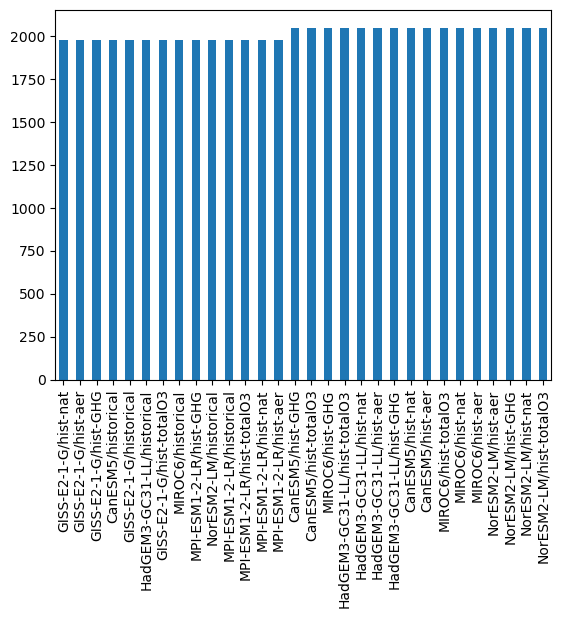

In [41]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.tas.sizes['time'])).sort_values().plot.bar()

In [42]:
lesfmip_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lon: 144, member: 50, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lon: 144, member: 30, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 709MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lon: 144, member: 50, lat: 20, time: 2052)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 2052, lat: 20, member: 10, lon: 144)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 236MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│           Data variables:
│               tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, time: 1980, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │      

In [43]:
# xr.DataTree.from_dict(dict(zip(list(lesfmip_tree), list(map(lambda leaf: leaf['historical'], lesfmip_tree.values())))))

In [44]:
opened_models = (pd.Series({a: [b for b in lesfmip_tree[a]] for a in lesfmip_tree})
    .explode()
    .rename_axis('protocal')
    .reset_index(name='model')
    .pipe(lambda d: pd.crosstab(d['model'], d['protocal']))).T

opened_models

model,hist-GHG,hist-aer,hist-nat,hist-totalO3,historical
protocal,,,,,
CanESM5,1,1,1,1,1
GISS-E2-1-G,1,1,1,1,1
HadGEM3-GC31-LL,1,1,1,1,1
MIROC6,1,1,1,1,1
MPI-ESM1-2-LR,1,1,1,1,1
NorESM2-LM,1,1,1,1,1


# Quantile Warming

In [45]:
import xarray_datatree_utils

In [46]:
reload(xarray_datatree_utils)

<module 'xarray_datatree_utils' from '/home/users/aborow/ExtAnt-initial/xarray_datatree_utils.py'>

In [47]:
from xarray_datatree_utils import skip_empty

## Functions

In [48]:
def seasonal_quantiles(ds, quantiles, dims=("member", "time")):
    """Quantiles per season, pooled over the given dims.

    Args:
        ds (xr.Dataset): Data with a `time` dim.
        quantiles (list[float]): Quantile levels in [0, 1].
        dims (tuple[str, ...]): Dims to pool over within each season.

    Returns:
        xr.Dataset: Quantiles with `season` and `quantile` dims.
    """
    return ds.groupby("time.season").quantile(quantiles, dim=list(dims))

In [49]:
@skip_empty
def generate_base_q(da):
    da = da.chunk({'member':-1, 'time':-1})
    q_hist_base = da.groupby('time.season').quantile(QUANTILES, dim=['time', 'member'])
    return q_hist_base

In [50]:
# @skip_empty
# def rolling_q(da):#
#     da = da.chunk({'member':-1, 'time':-1})
#     q_hist_base = da.resample(time='QS-DIC').quantile(QUANTILES, dim=['time', 'member']).compute()
#     return q_hist_base

In [51]:
@skip_empty
def split_season(ds):
    """Reshape a monthly time axis into year, season, monthofseason dims.

    Args:
        ds (xr.Dataset): Monthly data with a time dim.

    Returns:
        xr.Dataset: Data with time replaced by year, season, monthofseason.
    """
    month = ds.time.dt.month
    ds = ds.assign_coords(
        year=ds.time.dt.year + (month == 12),
        season=ds.time.dt.season,
        monthofseason=month % 3,
    )
    return ds.set_index(time=["year", "season", "monthofseason"]).unstack("time")

@skip_empty
def rolling_season_quantile(ds, quantiles, window=11, extra_dimensions=[]):
    """Centred rolling multi-year quantiles per season.

    Args:
        ds (xr.Dataset): Monthly data with member and time dims.
        quantiles (sequence of float): Quantile levels.
        window (int): Rolling window width in years.

    Returns:
        xr.Dataset: Quantiles with dims year, season, quantile.
    """
    split = split_season(ds).chunk({"season": -1, "monthofseason": -1})
    windows = split.rolling(year=window, center=True).construct("window")
    return windows.quantile(quantiles, dim=[*["window", "monthofseason"], *extra_dimensions])

In [52]:
@skip_empty
def space_mean(ds): return ds.mean(dim=['lat', 'lon'])

@skip_empty
def seasonal_mean(ds): return ds.resample(time='QS-DEC').mean()

In [53]:
@skip_empty
def coord_info(ds):
    name = next(iter(ds.data_vars))
    arr = ds[name].data
    return {
        **{("size", d): n for d, n in ds.sizes.items()},
        **{("chunk", d): n for d, n in zip(ds[name].dims, arr.chunksize)},
        ("memory", "mbytes"): int(ds.nbytes / 1024**2),
        ("memory", "chunk_mbytes"): round(float(np.prod(arr.chunksize) * arr.dtype.itemsize / 1024**2), 1),
        ("memory", "nchunks"): arr.npartitions
    }

In [54]:
def time_row(da, fmt="%Y-%m-%d", k=3):
    idx = da.indexes["time"]
    n = len(idx)
    labels = ([f"t{i}" for i in range(k)] + ["…"]
              + [f"t{i}" for i in range(-k, 0)] + ["n"])

    if n > 2 * k:
        head, tail, gap = idx[:k], idx[-k:], "…"
    else:
        h = -(-n // 2)                      # ceil(n / 2)
        head, tail, gap = idx[:h], idx[h:], ""

    vals = (list(head.strftime(fmt)) + [""] * (k - len(head))
            + [gap]
            + [""] * (k - len(tail)) + list(tail.strftime(fmt)))
    return pd.Series(vals + [n], index=labels)

In [55]:
"""LOWESS smoothing over an xarray grid, backed by statsmodels."""


from statsmodels.nonparametric.smoothers_lowess import lowess


def _lowess_1d(y, x, frac, it, delta):
    """Smooth one series, passing all-NaN input straight through.

    Parameters
    ----------
    y : (n,) array of values to smooth
    x : (n,) array of coordinate positions
    frac : float, fraction of points in each local window
    it : int, number of bisquare reweighting passes
    delta : float, distance within which fits are interpolated rather than computed

    Returns
    -------
    (n,) array of smoothed values, NaN where y is NaN
    """
    if not np.isfinite(y).any():
        return np.full_like(y, np.nan, dtype=float)
    return lowess(y, x, frac=frac, it=it, delta=delta, return_sorted=False)


def lowess_xarray(da, core_dims="year", window=81, it=3, delta=0.0):
    """Apply statsmodels LOWESS along one dimension of a DataArray.

    Parameters
    ----------
    da : DataArray to smooth
    core_dims : str, dimension to smooth along
    window : int, number of points in each local window
    it : int, number of bisquare reweighting passes; 0 disables robustness
    delta : float, interpolation distance in coordinate units; 0 fits every point

    Returns
    -------
    DataArray of smoothed values matching da
    """
    x = np.arange(da.sizes[core_dims])#da[core_dims].values.astype(float)
    frac = np.clip(window / da.sizes[core_dims], 0.0, 1.0)
    dims = da.dims
    if da.chunks is not None:
        da = da.chunk({core_dims: -1})
    return xr.apply_ufunc(
        _lowess_1d,
        da,
        input_core_dims=[[core_dims]],
        output_core_dims=[[core_dims]],
        kwargs={"x": x, "frac": frac, "it": it, "delta": delta},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    ).transpose(*dims)

In [56]:
from scipy import sparse

def lowess_matrix(n, frac):
    """Sparse hat matrix for local linear regression with tricube weights."""
    r = max(int(np.ceil(frac * n)), 2)
    x = np.arange(n, dtype=float)
    rows, cols, vals = [], [], []

    for i in range(n):
        lo = min(max(i - r // 2, 0), n - r)
        idx = np.arange(lo, lo + r)
        u = x[idx] - x[i]
        w = (1 - np.abs(u / np.abs(u).max()) ** 3) ** 3

        s0, s1, s2 = w.sum(), (w * u).sum(), (w * u**2).sum()
        l = w * (s2 - s1 * u) / (s0 * s2 - s1**2)

        rows.append(np.full(r, i))
        cols.append(idx)
        vals.append(l)

    return sparse.csr_matrix(
        (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
        shape=(n, n),
    )

@skip_empty
def lowess_matrix_xarray(da, core_dims='year', window:int=81):

    frac = window/da.sizes[core_dims]

    S = lowess_matrix(da.sizes[core_dims], frac=frac)
    
    smooth = xr.apply_ufunc(
        lambda y: (S @ y.reshape(-1, y.shape[-1]).T).T.reshape(y.shape),
        da,
        input_core_dims=[[core_dims]],
        output_core_dims=[[core_dims]],
        dask="parallelized",
        output_dtypes=[float],
    )

    return smooth

In [57]:
def _ring_index(levels, median):
    """Assign each consecutive quantile-level pair a ring index, 0 = adjacent to median.

    Args:
        levels (list[float]): Sorted quantile levels, including median.
        median (float): Quantile level treated as the band centre.

    Returns:
        list[int]: Ring index per consecutive pair, length len(levels) - 1.
    """
    median_idx = levels.index(median)
    rings = []
    for i in range(len(levels) - 1):
        rings.append(median_idx - (i + 1) if i + 1 <= median_idx else i - median_idx)
    return rings

def plot_fan(ax, da, quantiles, median=0.5, color="C0", alpha_min=0.15, alpha_max=0.6,
             lw=1.8, linestyle="-", label=None, band_labels=False,
             x_dim="year", quantile_dim="quantile"):
    """Draw adjacent, non-overlapping quantile bands and a median line on ax.

    Args:
        ax (plt.Axes): Axis to draw on.
        da (xr.DataArray): Dims (x_dim, quantile_dim).
        quantiles (Sequence[float]): Quantile levels excluding median, e.g. [0.1, 0.25, 0.75, 0.9].
        median (float): Quantile level drawn as a line and treated as the band centre.
        color (str): Band and line colour.
        alpha_min (float): Alpha of the outermost ring.
        alpha_max (float): Alpha of the ring(s) adjacent to the median.
        lw (float): Median line width.
        linestyle (str): Median line style.
        label (str | None): Legend entry for the median line.
        band_labels (bool): If True, label each band with its quantile range for the legend.
        x_dim (str): Name of the x coordinate.
        quantile_dim (str): Name of the quantile coordinate.

    Returns:
        plt.Line2D: The median line.
    """
    x = da[x_dim].values
    levels = sorted(set(quantiles) | {median})
    rings = _ring_index(levels, median)
    ring_alphas = np.linspace(alpha_max, alpha_min, max(rings) + 1)

    for i, ring in enumerate(rings):
        lo = da.sel({quantile_dim: levels[i]}, method="nearest").values
        hi = da.sel({quantile_dim: levels[i + 1]}, method="nearest").values
        band_label = f"{levels[i]:.0%}\u2013{levels[i + 1]:.0%}" if band_labels else None
        ax.fill_between(x, lo, hi, color=color, alpha=ring_alphas[ring], linewidth=0,
                         zorder=1, label=band_label)

    line, = ax.plot(x, da.sel({quantile_dim: median}).values, color=color,
                     linewidth=lw, linestyle=linestyle, zorder=3, label=label)
    return line

In [58]:
def plot_experiment_timeseries(point, colors, hue='member', variable='tas', ylim=None, figsize=None, row_height=1.2):
    experiments = list(point)

    if figsize is None:
        figsize = (10, row_height * len(experiments))

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(len(experiments), 1, hspace=0.05)
    axes = []

    for i, exp in enumerate(experiments):
        ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)

        da = point[exp][variable]
        color = colors.get(exp, f'C{i}') if isinstance(colors, dict) else colors[i]

        da.plot(ax=ax, hue=hue, color=color, add_legend=False, alpha=0.5)

        ax.set_ylabel(exp)
        ax.set_xlabel('')
        ax.set_title(None)
        ax.tick_params(axis='x', labelbottom=False, bottom=False)

        if ylim is not None:
            ax.set_ylim(ylim)

        formatting.style_ax(ax)

    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position('top')
    axes[0].tick_params(axis='x', labeltop=True, top=True)
    axes[0].set_xlabel('Year')

    axes[-1].tick_params(axis='x', labelbottom=True, bottom=True)
    axes[-1].set_xlabel('Year')

    return fig, axes

In [59]:
@skip_empty
def rolling_std(da, window=11, dim=['window', 'member']):
    return da.rolling(year=window, center=True).construct('window').std(dim=dim)

In [60]:
PLOT_QUANTILES = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

## Quantile calc

<Axes: >

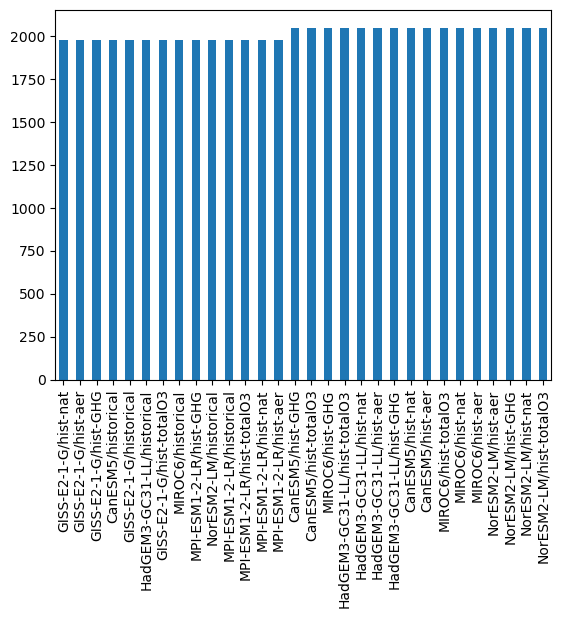

In [61]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['time'])).sort_values().plot.bar()

In [62]:
lesfmip_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lon: 144, member: 50, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lon: 144, member: 30, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 709MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lon: 144, member: 50, lat: 20, time: 2052)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 2052, lat: 20, member: 10, lon: 144)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 236MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│           Data variables:
│               tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, time: 1980, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │      

In [63]:
# ensemble_members_numbers = pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['member'], multi_index=True)).sort_values()

member_counts = pd.Series(
    map_to_dict(lesfmip_tree, lambda ds: ds.sizes["member"], multi_index=True)
)
member_counts.index.names = ["model", "experiment"]
member_counts_grid = member_counts.unstack("experiment")

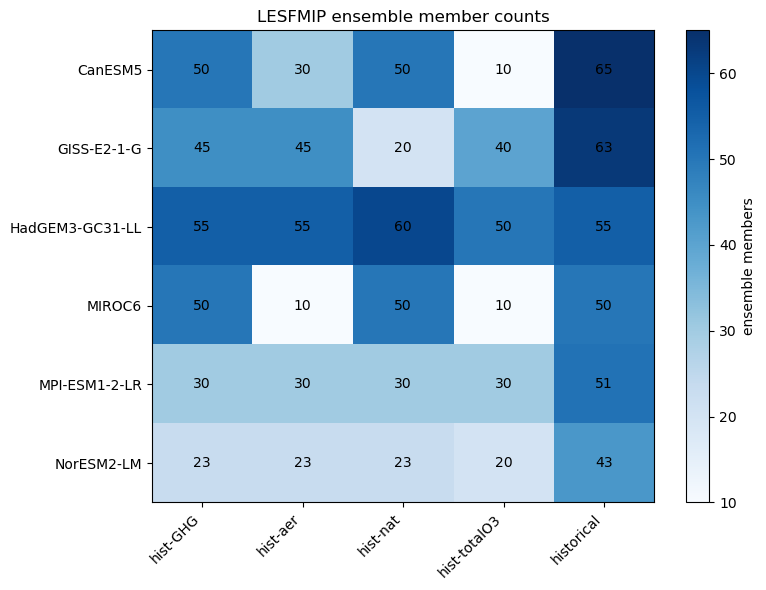

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("lightgrey")

im = ax.imshow(member_counts_grid.values.astype(float), cmap=cmap, aspect="auto")

ax.set_xticks(range(len(member_counts_grid.columns)))
ax.set_xticklabels(member_counts_grid.columns, rotation=45, ha="right")
ax.set_yticks(range(len(member_counts_grid.index)))
ax.set_yticklabels(member_counts_grid.index)

for i in range(member_counts_grid.shape[0]):
    for j in range(member_counts_grid.shape[1]):
        val = member_counts_grid.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, int(val), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="ensemble members")
ax.set_title("LESFMIP ensemble member counts")
fig.tight_layout()

Text(0.5, 1.0, 'NUmber of Ensemble Members')

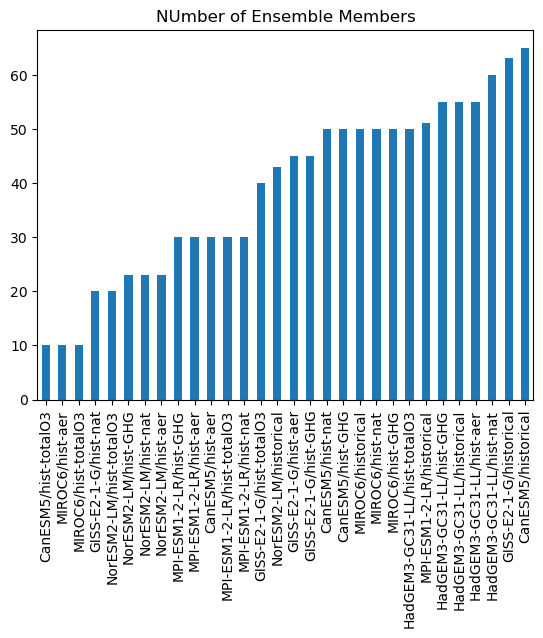

In [65]:
pd.Series(map_to_dict(lesfmip_tree, lambda ds: ds.sizes['member'])).sort_values().plot.bar()
plt.title('NUmber of Ensemble Members')

In [66]:
#(t): Defining quantiles
QUANTILES = np.array([0.9, 0.95, 0.99])
QUANTILES = np.sort(np.concatenate([1-QUANTILES, [0.5], QUANTILES])).round(2)
QUANTILES

array([0.01, 0.05, 0.1 , 0.5 , 0.9 , 0.95, 0.99])

In [67]:
#(t): Converting from K to C
lesfmip_tree = lesfmip_tree - 273.15

In [68]:
# chunks = {'time':-1, 'member': -1, 'lat':4, 'lon':-1}
chunks = {'time': -1, 'member': -1, 'lat': 4, 'lon': -1}
lesfmip_tree = lesfmip_tree.chunk(chunks)

In [69]:
#(t): Seaosonal average
lesfmip_tree = lesfmip_tree.map_over_datasets(seasonal_mean).isel(time=slice(1, -1))

In [70]:
# pd.DataFrame.from_dict(pprint(map_to_dict(lesfmip_tree, time_info)))

In [71]:
#(t): This is the time step that matches between them all
#(c): TODO: For those that have an extend, this might make them all the same legnth
lesfmip_tree = lesfmip_tree.sel(time=slice(None, '2014-09-01'))

In [72]:
data_info = pd.DataFrame.from_dict(
    map_to_dict(
        lesfmip_tree, 
        coord_info),
    orient='index')
data_info.head()

size                 chunk                 memory  \
                     time member lat  lon  time member lat  lon mbytes   
CanESM5/hist-GHG      659     50  20  144   659     50   4  144    362   
CanESM5/hist-aer      659     30  20  144   659     30   4  144    217   
CanESM5/hist-nat      659     50  20  144   659     50   4  144    362   
CanESM5/hist-totalO3  659     10  20  144   659     10   4  144     72   
CanESM5/historical    659     65  20  144   659     65   4  144    941   

                                           
                     chunk_mbytes nchunks  
CanESM5/hist-GHG             72.4       5  
CanESM5/hist-aer             43.4       5  
CanESM5/hist-nat             72.4       5  
CanESM5/hist-totalO3         14.5       5  
CanESM5/historical          188.2       5

In [73]:
# (t): Sort by the sizes
data_info_sorted = data_info.sort_values(by=('memory', 'mbytes'), ascending=False)
sorted_model_experiments = data_info_sorted.index.values
sorted_model_experiments[:5]

array(['CanESM5/historical', 'MPI-ESM1-2-LR/historical',
       'GISS-E2-1-G/historical', 'HadGEM3-GC31-LL/hist-nat',
       'HadGEM3-GC31-LL/hist-aer'], dtype=object)

In [74]:
%%time
client.cluster.scale(20)
client.wait_for_workers(12)

CPU times: user 3.83 ms, sys: 3.15 ms, total: 6.97 ms
Wall time: 30.8 ms


In [75]:
%%time
#(t): The quantiles of the base period
q_histnat_base_tree = xarray_datatree_utils.take_level(lesfmip_tree, 'hist-nat').map_over_datasets(generate_base_q).compute()

CPU times: user 132 ms, sys: 12.2 ms, total: 144 ms
Wall time: 36.6 s


In [76]:
%%time
#(t): Calculting rolling quantiles over all datasets
lesfmip_tree_rolling_q = lesfmip_tree.map_over_datasets(
    partial(rolling_season_quantile, quantiles=QUANTILES, extra_dimensions=['member'])
).compute()

CPU times: user 4.41 s, sys: 3.37 s, total: 7.78 s
Wall time: 5min 15s


In [77]:
# pd.Series(map_to_dict(lesfmip_tree_rolling_q, lambda ds: ds.sizes['year'])).sort_values().plot.bar()

In [78]:
%%time
lesfmip_tree_smooth_q = lesfmip_tree_rolling_q.map_over_datasets(lowess_matrix_xarray).compute()

CPU times: user 21.6 s, sys: 2.46 s, total: 24.1 s
Wall time: 24.3 s


In [79]:
# %%time
#(t): Smoothing with lowess
# lesfmip_tree_smooth_q = lesfmip_tree_rolling_q['CanESM5'].map_over_datasets(lowess_xarray)

In [80]:
lesfmip_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (time: 659, member: 50, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│   │       Data variables:
│   │           tas      (time, member, lat, lon) float32 380MB dask.array<chunksize=(659, 50, 4, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (time: 659, member: 30, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │         * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│   │       Data variables:
│   │           tas      (time, member, lat, lon) float32 228MB dask.array<chunksize=(659, 30, 4, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (time: 659, member: 50, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │         * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│   │       Data variables:
│   │           tas      (time, member, lat, lon) float32 380MB dask.array<chunksize=(659, 50, 4, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 659, member: 10, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │         * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│   │       Data variables:
│   │           tas      (time, member, lat, lon) float32 76MB dask.array<chunksize=(659, 10, 4, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (time: 659, member: 65, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│             * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│           Data variables:
│               tas      (time, member, lat, lon) float64 987MB dask.array<chunksize=(659, 65, 4, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (time: 659, member: 45, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 5kB 1850-03-01 00:00:00 ... 2014-09-01 00:00:00
│   │       Data variables:
│   │           tas    

In [85]:
#(t): That change of the intensity of the quantiles
#(c): space x time
lesfmip_tree_change_quantile = xr.DataTree.from_dict(
    {key: xarray_datatree_utils.to_dataset(lesfmip_tree_smooth_q[key], concat_dim='experiment') - q_histnat_base_tree[key] for key in q_histnat_base_tree})

In [86]:
lesfmip_tree_change_quantile

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│       Dimensions:     (lon: 144, lat: 20, quantile: 7, season: 4, year: 165,
│                        experiment: 5)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│         * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season, year) float64 532MB ...
├── Group: /GISS-E2-1-G
│       Dimensions:     (lon: 144, lat: 20, quantile: 7, season: 4, year: 165,
│                        experiment: 5)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│           height      float64 8B 2.0
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│         * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season, year) float64 532MB ...
├── Group: /HadGEM3-GC31-LL
│       Dimensions:     (lon: 144, lat: 20, quantile: 7, season: 4, year: 165,
│                        experiment: 5)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│           height      float64 8B 1.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│         * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season, year) float64 532MB ...
├── Group: /MIROC6
│       Dimensions:     (lon: 144, lat: 20, quantile: 7, season: 4, year: 165,
│                        experiment: 5)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│         * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season, year) float64 532MB ...
├── Group: /MPI-ESM1-2-LR
│       Dimensions:     (lon: 144, lat: 20, quantile: 7, season: 4, year: 165,
│                        experiment: 5)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│         * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (

In [87]:
#(t): Final anomaly
#(c): space only
final_change_quantile = lesfmip_tree_change_quantile.isel(year=-1)
final_change_quantile

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│       Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│           year        int64 8B 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season) float64 3MB 2.647 .....
├── Group: /GISS-E2-1-G
│       Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│           height      float64 8B 2.0
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│           year        int64 8B 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season) float64 3MB 2.076 .....
├── Group: /HadGEM3-GC31-LL
│       Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│           height      float64 8B 1.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│           year        int64 8B 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season) float64 3MB 1.842 .....
├── Group: /MIROC6
│       Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│           year        int64 8B 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season) float64 3MB 0.3048 ....
├── Group: /MPI-ESM1-2-LR
│       Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
│       Coordinates:
│         * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
│         * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height      float64 8B 2.0
│         * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
│         * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│           year        int64 8B 2014
│         * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
│       Data variables:
│           tas         (experiment, quantile, lat, lon, season) float64 3MB 1.643 .....
└── Group: /NorESM2-LM
        Dimensions:     (experiment: 5, quantile: 7, lat: 20, lon: 144, season: 4)
        Coordinates:
          * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
          * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
            height      float64 8B 2.0
          *

In [88]:
#(t): Space mean
lesfmip_tree_smooth_q_smean = lesfmip_tree_change_quantile.map_over_datasets(space_mean)

## ToE Methods

### Functions

In [89]:
from scipy.ndimage import gaussian_filter1d


In [90]:
def _fast_kde_block(arr, x, bandwidth):
    """
    arr has shape (..., sample)
    """

    original_shape = arr.shape[:-1]
    nsample = arr.shape[-1]

    arr = arr.reshape(-1, nsample)

    nseries = arr.shape[0]
    nx = len(x)

    dx = x[1] - x[0]

    edges = np.concatenate([
        [x[0] - dx / 2],
        (x[:-1] + x[1:]) / 2,
        [x[-1] + dx / 2],
    ])

    # Flatten all values
    values = arr.ravel()

    valid = (
        np.isfinite(values)
        & (values >= edges[0])
        & (values <= edges[-1])
    )

    positions = np.flatnonzero(valid)

    # Which KDE does each value belong to?
    rows = positions // nsample

    # Which x bin?
    bins = np.searchsorted(
        edges,
        values[valid],
        side="right",
    ) - 1

    bins = np.clip(bins, 0, nx - 1)

    # Convert (row, bin) -> one-dimensional index
    indices = rows * nx + bins

    hist = np.bincount(
        indices,
        minlength=nseries * nx,
    ).reshape(nseries, nx)

    # Number of finite values in each KDE
    n = np.isfinite(arr).sum(axis=-1)

    # Avoid division by zero
    density_hist = np.divide(
        hist,
        n[:, None] * dx,
        out=np.full_like(hist, np.nan, dtype=float),
        where=n[:, None] > 0,
    )

    sigma = bandwidth / dx

    density = gaussian_filter1d(
        density_hist,
        sigma=sigma,
        axis=-1,
        mode="constant",
    )

    return density.reshape(*original_shape, nx)

def fast_kde_xr(da, x, dim="time", bandwidth="scott"):

    x = np.asarray(x)

    # --------------------------------------------
    # Accept either:
    #
    # dim="time"
    #
    # or:
    #
    # dim=["window", "member"]
    # --------------------------------------------
    if isinstance(da, xr.Dataset):
        var_name = list(da.data_vars)[0]
        da = da[var_name]
    else:
        var_name = da.name or "kde"
    
    if isinstance(da, xr.Dataset): da = da.to_array().squeeze('variable', drop=True)

    if isinstance(dim, str):
        dims = [dim]
    else:
        dims = list(dim)

    # --------------------------------------------
    # Stack sample dimensions
    # --------------------------------------------

    if len(dims) > 1:

        sample_dim = "__sample__"

        da = da.stack(
            {sample_dim: dims}
        )

    else:
        sample_dim = dims[0]

    # Make sure complete sample axis is available
    # within each dask block
    if da.chunks is not None:
        da = da.chunk({
            sample_dim: -1
        })

    # --------------------------------------------
    # Common bandwidth
    # --------------------------------------------

    if bandwidth == "scott":

        n = da.count(
            dim=sample_dim
        )

        std = da.std(
            dim=sample_dim,
            skipna=True,
            ddof=1,
        )

        bw = std * n ** (-1 / 5)

        # One bandwidth shared across all KDEs
        bandwidth = float(
            np.nanmedian(
                bw.compute().values
            )
        )

    else:

        bandwidth = float(bandwidth)

    # --------------------------------------------
    # KDE
    # --------------------------------------------

    result = xr.apply_ufunc(
        _fast_kde_block,
        da,

        input_core_dims=[
            [sample_dim]
        ],

        output_core_dims=[
            ["x"]
        ],

        kwargs={
            "x": x,
            "bandwidth": bandwidth,
        },

        vectorize=False,
        dask="parallelized",

        output_dtypes=[
            float
        ],

        dask_gufunc_kwargs={
            "output_sizes": {
                "x": len(x)
            }
        },
    )

    result = result.assign_coords(x=x)
    result = result.xarray_datatree_utils.to_dataset(name = var_name)

    return result

In [91]:
import xarray_calc
@skip_empty
def rolling_seasonal_mean(da):
    da = da.resample(time='QS-DEC').mean()
    da = xarray_calc.split_time(da, ('year', 'season'), 'time')
    return da

In [265]:
def return_statistical_pvalue(arr1, arr2, stats_test):
    """
    Calculate the p-value for a given statistical test for two arrays.

    Parameters:
    arr1 (numpy array): The first input array.
    arr2 (numpy array): The second input array.

    Returns:
    float: The p-value of the specified statistical test.

    Notes:
    If either array contains only NaN values, the function returns NaN.
    """
    # Check if all values are nan
    if np.all(np.isnan(arr1)) or np.all(np.isnan(arr2)): return np.nan
    arr1, arr2 = remove_nans(arr1, arr2)

    return stats_test(arr1, arr2).pvalue

In [329]:

from scipy.special import stdtr

@skip_empty
def ttest_welch(
    da1: xr.DataArray,
    da2: xr.DataArray,
    dims: tuple[str, ...] = ("year", "member"),
) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Perform a Welch's t-test across specified dimensions.

    Parameters
    ----------
    da1 (xr.DataArray): First distribution.
    da2 (xr.DataArray): Second distribution.
    dims (tuple[str, ...]): Dimensions to reduce over.

    Returns
    -------
    t (xr.DataArray): T-statistic.
    p (xr.DataArray): Two-sided p-value.
    """
    n1 = np.prod([da1.sizes[d] for d in dims])
    n2 = np.prod([da2.sizes[d] for d in dims])

    print(n1, n2)

    m1, m2 = da1.mean(dims), da2.mean(dims)
    v1, v2 = da1.var(dims, ddof=1), da2.var(dims, ddof=1)

    print(m1, m2)
    print(v1, v2)

    se2 = v1 / n1 + v2 / n2
    t = (m1 - m2) / np.sqrt(se2)

    df = se2**2 / (
        (v1 / n1) ** 2 / (n1 - 1)
        + (v2 / n2) ** 2 / (n2 - 1)
    )

    p = xr.apply_ufunc(
        lambda t, df: 2 * stdtr(df, -np.abs(t)),
        t,
        df,
        dask="parallelized",
        output_dtypes=[float],
    )
    t = t.rename({list(t)[0] :'t'})
    p = t.rename({list(t)[0] :'p'})
    out = xr.merge([t, p])

    return out

### All data

In [93]:
lesfmip_tree_seasonal_mean = lesfmip_tree.map_over_datasets(rolling_seasonal_mean)

In [293]:
lesfmip_tree_seasonal_mean['CanESM5']

<xarray.DataTree 'CanESM5'>
Group: /CanESM5
├── Group: /CanESM5/hist-GHG
│       Dimensions:  (year: 165, season: 4, lon: 144, member: 50, lat: 20)
│       Coordinates:
│         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height   float64 8B 2.0
│       Data variables:
│           tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /CanESM5/hist-aer
│       Dimensions:  (year: 165, season: 4, lon: 144, member: 30, lat: 20)
│       Coordinates:
│         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height   float64 8B 2.0
│       Data variables:
│           tas      (member, lat, lon, year, season) float32 228MB dask.array<chunksize=(30, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /CanESM5/hist-nat
│       Dimensions:  (year: 165, season: 4, lon: 144, member: 50, lat: 20)
│       Coordinates:
│         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           height   float64 8B 2.0
│       Data variables:
│           tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /CanESM5/hist-totalO3
│       Dimensions:  (year: 165, season: 4, lat: 20, lon: 144, member: 10)
│       Coordinates:
│         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│           height   float64 8B 2.0
│       Data variables:
│           tas      (member, lat, lon, year, season) float32 76MB dask.array<chunksize=(10, 4, 144, 164, 4), meta=np.ndarray>
└── Group: /CanESM5/historical
        Dimensions:  (year: 165, season: 4, lon: 144, member: 65, lat: 20)
        Coordinates:
          * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
          * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
          * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
          * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
          * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
            height   float64 8B 2.0
        Data variables:
            tas      (member, lat, lon, year, season) float64 988MB dask.array<chunksize=(65, 4, 144, 164, 4), meta=np.ndarray>

In [299]:
xr.map_over_datasets

<function xarray.core.datatree_mapping.map_over_datasets(func: 'Callable[..., Dataset | tuple[Dataset | None, ...] | None]', *args: 'Any', kwargs: 'Mapping[str, Any] | None' = None) -> 'DataTree | tuple[DataTree, ...]'>

In [ ]:
out = ttest_welch(
    lesfmip_tree_seasonal_mean['CanESM5']['hist-nat'].dataset.isel(year=slice(0, 20)),
    lesfmip_tree_seasonal_mean['CanESM5']['hist-nat'].dataset.isel(year=slice(0, 20)),
    dims= ("year", "member")

).compute()

1000 1000
<xarray.Dataset> Size: 47kB
Dimensions:  (lat: 20, lon: 144, season: 4)
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height   float64 8B 2.0
Data variables:
    tas      (lat, lon, season) float32 46kB dask.array<chunksize=(4, 144, 4), meta=np.ndarray> <xarray.Dataset> Size: 47kB
Dimensions:  (lat: 20, lon: 144, season: 4)
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height   float64 8B 2.0
Data variables:
    tas      (lat, lon, season) float32 46kB dask.array<chunksize=(4, 144, 4), meta=np.ndarray>
<xarray.Dataset> Size: 47kB
Dimensions:  (lat: 20, lon: 144, season: 4)
Coordinates:
  * season   (season) <U3 48B

In [328]:
# out.isel(season=0).p.plot()

In [322]:
out.t.isel(lat=0, lon=0)#.plot(hue='season');

<xarray.DataArray 't' (season: 4)> Size: 32B
dask.array<chunksize=(4,), meta=np.ndarray>
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
    lon      float64 8B -180.0
    lat      float64 8B -87.5
    height   float64 8B 2.0

In [315]:
t.rename({list(t)[0] :'t'})

<xarray.Dataset> Size: 94kB
Dimensions:  (season: 4, lon: 144, lat: 20)
Coordinates:
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height   float64 8B 2.0
Data variables:
    t        (lat, lon, season) float64 92kB dask.array<chunksize=(4, 144, 4), meta=np.ndarray>

In [313]:
list(t)

['tas']

In [302]:
ttest_da = xr.map_over_datasets(
    ttest_welch,
    lesfmip_tree_seasonal_mean['CanESM5'],
    lesfmip_tree_seasonal_mean['CanESM5']['hist-nat'].dataset,
    kwargs={"dims": ("year", "member")}
)

TypeError: Calling func on the nodes at position hist-GHG returns a tuple of 2 datasets, whereas calling func on the nodes at position . instead returns a single dataset.

In [291]:
xr.map_over_datasets

<function xarray.core.datatree_mapping.map_over_datasets(func: 'Callable[..., Dataset | tuple[Dataset | None, ...] | None]', *args: 'Any', kwargs: 'Mapping[str, Any] | None' = None) -> 'DataTree | tuple[DataTree, ...]'>

In [290]:
lesfmip_tree_seasonal_mean.match('*/hist-nat')

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   └── Group: /CanESM5/hist-nat
│           Dimensions:  (member: 50, lat: 20, lon: 144, year: 165, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   └── Group: /GISS-E2-1-G/hist-nat
│           Dimensions:  (member: 20, lat: 20, lon: 144, year: 165, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│             * member   (member) object 160B 'r10i1p1f3' 'r1i1p1f2' ... 'r9i1p1f3'
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 152MB dask.array<chunksize=(20, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /HadGEM3-GC31-LL
│   └── Group: /HadGEM3-GC31-LL/hist-nat
│           Dimensions:  (member: 60, lat: 20, lon: 144, year: 165, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│             * member   (member) object 480B 'r10i1p1f3' 'r11i1p1f3' ... 'r9i1p1f3'
│               height   float64 8B 1.5
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 456MB dask.array<chunksize=(60, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /MIROC6
│   └── Group: /MIROC6/hist-nat
│           Dimensions:  (member: 50, lat: 20, lon: 144, year: 165, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│             * member   (member) object 400B 'r10i1p1f1' 'r11i1p1f1' ... 'r9i1p1f1'
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 380MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /MPI-ESM1-2-LR
│   └── Group: /MPI-ESM1-2-LR/hist-nat
│           Dimensions:  (member: 30, lat: 20, lon: 144, year: 165, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│             * member   (member) object 240B 'r10i1p1f2' 'r11i1p1f2' ... 'r9i1p1f2'
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 228MB dask.array<chunksize=(30, 4, 144, 164, 4), meta=np.ndarray>
└── Group: /NorESM2-LM
    └──

In [94]:
base_mean = lesfmip_tree_seasonal_mean.mean(dim=['year', 'member'])

In [95]:
lesfmip_tree_seasonal_anom = lesfmip_tree_seasonal_mean - base_mean

In [96]:
lesfmip_tree_mm_signal = lesfmip_tree_seasonal_anom.mean(dim='member')

In [97]:
lesfmip_tree_mm_signal = lesfmip_tree_mm_signal.map_over_datasets(skip_empty(lowess_xarray), kwargs=dict(core_dims='year')).compute()

In [98]:
rolling_std

<function __main__.rolling_std(da, window=11, dim=['window', 'member'])>

In [116]:
lesfmip_tree_seasonal_noise = xarray_datatree_utils.take_level(lesfmip_tree_seasonal_mean, 'hist-nat').std(dim=['member', 'year'])
lesfmip_tree_seasonal_noise = xr.DataTree.from_dict({key: branch['hist-nat'] for key, branch in lesfmip_tree_seasonal_mean.items()}).std(dim=['member', 'year'])

In [100]:
lesfmip_detrend = lesfmip_tree_seasonal_anom - lesfmip_tree_mm_signal

In [101]:
# lesfmip_histnat_noise = xarray_datatree_utils.take_level(lesfmip_detrend, 'hist-nat').map_over_datasets(rolling_std)
lesfmip_experiment_noise = lesfmip_detrend.map_over_datasets(rolling_std)

In [285]:
lesfmip_experiment_noise_da = xarray_datatree_utils.tree_to_dataset(
    lesfmip_experiment_noise, dims=['experiment', 'model']).drop_vars('height')

In [286]:
lesfmip_experiment_noise_da

<xarray.Dataset> Size: 456MB
Dimensions:     (experiment: 6, model: 5, lat: 20, lon: 144, year: 165,
                 season: 4)
Coordinates:
  * experiment  (experiment) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * model       (model) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
Data variables:
    tas         (lat, lon, year, season, experiment, model) float64 456MB dask.array<chunksize=(2, 72, 159, 2, 1, 1), meta=np.ndarray>

In [280]:
# lesfmip_experiment_noise_da = xr.concat(
#     [
#         xarray_datatree_utils.to_dataset(branch, concat_dim='experiment').assign_coords(model=model) for model, branch in lesfmip_experiment_noise.items()
#     ], dim='model')

In [103]:
ALL_BUT_HISTNAT = [str(exp) for exp in lesfmip_experiment_noise_da.experiment.values if exp != 'hist-nat']
ALL_BUT_HISTNAT

['hist-GHG', 'hist-aer', 'hist-totalO3', 'historical']

In [104]:
lesfmip_noise_da = np.sqrt(
    1/2 * (
        lesfmip_experiment_noise_da.sel(experiment='hist-nat')**2 + lesfmip_experiment_noise_da**2
    )
)

In [268]:
xarray_datatree_utils.tree_to_dataset

<function xarray_datatree_utils.tree_to_dataset(dt: xarray.core.datatree.DataTree, dims: list[str], **concat_kwargs) -> xarray.core.dataset.Dataset>

In [270]:
reload(xarray_datatree_utils)

<module 'xarray_datatree_utils' from '/home/users/aborow/ExtAnt-initial/xarray_datatree_utils.py'>

In [271]:
lesfmip_mm_signal_da = xarray_datatree_utils.tree_to_dataset(
    lesfmip_tree_mm_signal, dims=['model', 'experiment']).drop_vars('height')

In [276]:
lesfmip_mm_signal_da

<xarray.Dataset> Size: 456MB
Dimensions:     (model: 6, experiment: 5, lat: 20, lon: 144, year: 165,
                 season: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height      (model, experiment) float64 240B 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0
Data variables:
    tas         (lat, lon, year, season, model, experiment) float64 456MB -0....

In [277]:
# lesfmip_mm_signal_da = xr.concat(
#     [
#         xarray_datatree_utils.to_dataset(branch, concat_dim='experiment').assign_coords(model=model)
#         for model, branch in lesfmip_tree_mm_signal.items()
#     ], dim='model')

In [106]:
lesfmip_seasonal_sn_da = lesfmip_mm_signal_da/lesfmip_experiment_noise_da

In [107]:
lesfmip_seasonal_sn_da = lesfmip_seasonal_sn_da.compute()
lesfmip_mm_signal_da = lesfmip_mm_signal_da.compute()
lesfmip_noise_da = lesfmip_noise_da.compute()

In [108]:
# reload(xarray_datatree_utils)

In [109]:
# lesfmip_experiment_noise.map_over_datasets(xarray_datatree_utils.to_dataset, kwargs={'concat_dim': 'experiment'})

In [110]:
# lesfmip_experiment_noise + xarray_datatree_utils.take_level(lesfmip_experiment_noise, 'hist-nat')

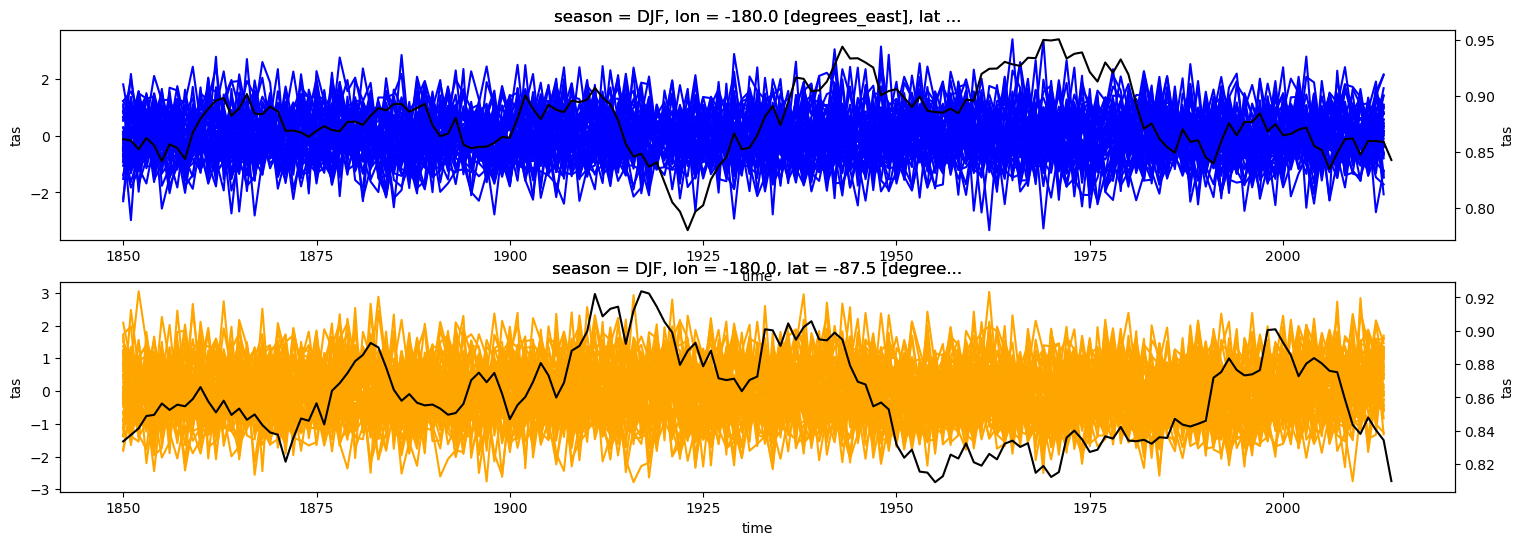

In [111]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6))

ax1_twinx = ax1.twinx()
ax2_twinx = ax2.twinx()

lesfmip_detrend['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax1, hue='member', color='blue', add_legend=False);
lesfmip_detrend['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax2, hue='member', color='orange', add_legend=False);

lesfmip_experiment_noise['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax1_twinx, label='histnat', color='black')
lesfmip_experiment_noise['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(ax=ax2_twinx, label='hist', color='black')

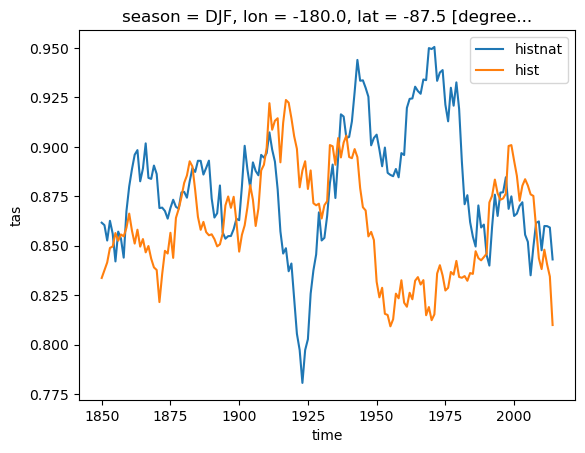

In [112]:
lesfmip_experiment_noise['CanESM5']['hist-nat'].isel(season=0, lat=0, lon=0).tas.plot(label='histnat')
lesfmip_experiment_noise['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot(label='hist')
plt.legend()

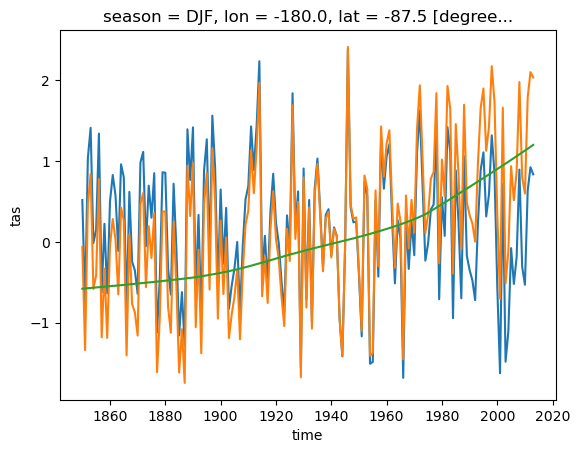

In [113]:
lesfmip_detrend['CanESM5']['historical'].isel(season=0, lat=0, lon=0, member=0).tas.plot()
lesfmip_tree_seasonal_anom['CanESM5']['historical'].isel(season=0, lat=0, lon=0, member=0).tas.plot()
lesfmip_tree_mm_signal['CanESM5']['historical'].isel(season=0, lat=0, lon=0).tas.plot()

In [118]:
lesfmip_tree_seasonal_sn =xr.DataTree.from_dict({key: lesfmip_tree_mm_signal[key]/lesfmip_tree_seasonal_noise[key].tas for key in lesfmip_tree_mm_signal.keys()})

In [119]:
lesfmip_tree_seasonal_sn = lesfmip_tree_seasonal_sn.compute()

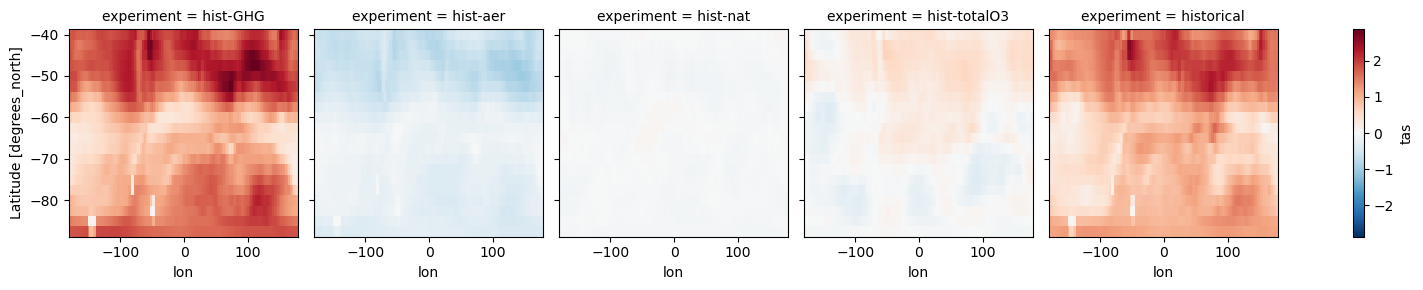

In [120]:
lesfmip_seasonal_sn_da.sel(model='CanESM5').isel(season=0, year=-10).plot(col='experiment')

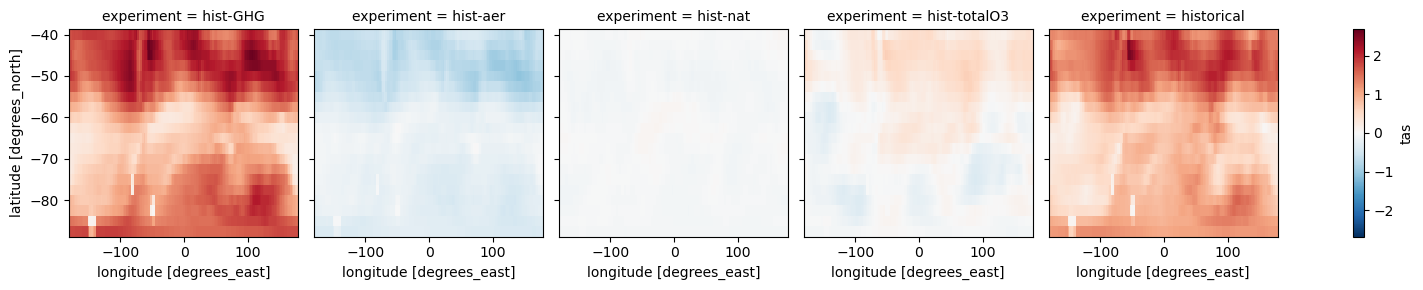

In [122]:
xarray_datatree_utils.to_dataset(lesfmip_tree_seasonal_sn['CanESM5'], concat_dim='experiment').isel(season=0, year=-10).plot(col='experiment')

### Testing

In [ ]:
# (t): Test subset

# subset_tree = xr.DataTree.from_dict({
#     k: lesfmip_tree['CanESM5'][k] for k in ('historical', 'hist-nat')
# }).isel(lat=slice(0, 10), lon=slice(0, 10))
subset_tree = lesfmip_tree['CanESM5'].isel(lat=slice(0, 4), lon=slice(0, 4))

In [ ]:
# subset_da = xarray_datatree_utils.to_dataset(subset_tree)

In [ ]:
%%time
lesfmip_tree_rolling_member_q = subset_tree.map_over_datasets(
    rolling_season_quantile,
    kwargs={"quantiles": QUANTILES, "extra_dimensions": []},
).compute()

In [ ]:
point =  subset_tree.isel(lat=0, lon=0).map_over_datasets(rolling_seasonal_mean).compute().isel(season=0)#.resample(time='YE').mean()

In [ ]:
# point['historical'].tas.isel(member=0).plot(hue='season');

In [ ]:
point_quant = lesfmip_tree_rolling_member_q.isel(season=0, lat=0, lon=0).sel(quantile=0.5).compute()
point_quant

In [ ]:
base_mean = point['hist-nat'].mean(dim=['member', 'year']).tas
base_mean

In [ ]:
point_anom = point - base_mean

In [ ]:
point_signal = point_anom.map_over_datasets(skip_empty(lowess_xarray), kwargs=dict(core_dims='year')).compute()

In [ ]:
point_anom['hist-GHG'].tas.plot(hue='member', color='grey', add_legend=False);
point_signal['hist-GHG'].tas.plot(hue='member', color='blue', add_legend=False);


In [ ]:
point_signal_mean = point_signal.mean(dim='member')

In [ ]:
point_noise = point_anom['historical'].tas.std(dim=['year', 'member'])

In [ ]:
point_sn = point_signal/point_noise

In [ ]:
difference_member_mean = point_anom - point_signal_mean

In [ ]:
@skip_empty
def rolling_quantile(da, q):
    return da.rolling(year=21, center=True).construct('window').quantile(dim=['window', 'member'], q=q)

In [ ]:
# @skip_empty
# def rolling_iqr(da):
#     return da.rolling(year=11, center=True).construct('window').std(dim=['window', 'member'])

In [ ]:
# difference_member_mean

In [ ]:
rolling_iqr = xarray_datatree_utils.to_dataset(
    difference_member_mean.map_over_datasets(rolling_quantile, kwargs=dict(q=0.75))
    -
    difference_member_mean.map_over_datasets(rolling_quantile, kwargs=dict(q=0.25))
)

In [ ]:
# point_rolling_std = xarray_datatree_utils.to_dataset(difference_member_mean.map_over_datasets(rolling_std))

In [ ]:
rolling_iqr

In [ ]:
point_anom['hist-aer'].tas.plot(hue='member', add_legend=False, color='grey');
point_signal['hist-aer'].tas.plot(hue='member', color='blue', alpha=0.1, add_legend=False);

point_signal_mean['hist-aer'].tas.plot(color='red')


In [ ]:
fig, axes = plot_experiment_timeseries(difference_member_mean, constants.FORCING_COLORS)#, ylim=(-29, -22))
plt.show()

In [ ]:
def plot_experiment_dataarray(da, colors, experiment_dim='experiment', ylim=None, figsize=None, row_height=1.2):
    experiments = da[experiment_dim].values

    if figsize is None:
        figsize = (10, row_height * len(experiments))

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(len(experiments), 1, hspace=0.1)
    axes = []

    for i, exp in enumerate(experiments):
        ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)

        color = colors.get(exp, f'C{i}') if isinstance(colors, dict) else colors[i]
        da.sel({experiment_dim: exp}).plot(ax=ax, color=color, add_legend=False)

        ax.set_ylabel(exp, color=color)
        ax.set_xlabel('')
        ax.set_title(None)
        ax.tick_params(axis='x', labelbottom=False, bottom=False)

        if ylim is not None:
            ax.set_ylim(ylim)

        formatting.style_ax(ax)

    axes[0].xaxis.tick_top()
    axes[0].xaxis.set_label_position('top')
    axes[0].tick_params(axis='x', labeltop=True, top=True)
    axes[0].set_xlabel('Year')

    axes[-1].tick_params(axis='x', labelbottom=True, bottom=True)
    axes[-1].set_xlabel('Year')

    return fig, axes

In [ ]:
fig, axes = plot_experiment_dataarray(rolling_iqr, constants.FORCING_COLORS)

fig.suptitle('Change in variance')

In [ ]:
rolling_iqr.plot(hue='experiment');

In [ ]:
difference_member_mean['historical'].tas.plot(hue='member', add_legend=False);

In [ ]:
point_anom['historical'].tas.mean(dim='member').plot()#.plot(hue='member', add_legend=False);
point_signal['historical'].tas.mean(dim='member').plot()#.plot(hue='member', add_legend=False);

In [ ]:
x = np.linspace(-29, -20, 500)

In [ ]:
construct_window = lambda da: da.rolling(year=3, center=True).construct('window')
construct_window = skip_empty(construct_window)

In [ ]:
point_window = point.map_over_datasets(construct_window).chunk({'member':-1, 'window':-1})

In [ ]:
point_member_year_kde = point_window.map_over_datasets(
    skip_empty(fast_kde_xr), kwargs={'x':x, 'dim':['window', 'member']})

In [ ]:
periods = np.arange(1900, 2020, 20)#[1900, 1950, 2000]

In [ ]:
fig, axes = distributions.kde_overlay(point_member_year_kde, periods, constants.FORCING_COLORS)#, mode="overlay")

In [ ]:
distributions.hist_grid

In [ ]:
years = np.arange(1900, 2010, 20)

slice_length = 2
years = [slice(year-slice_length, year+slice_length) for year in years]

fig, axes = distributions.hist_grid(point, periods=years, colors=constants.FORCING_COLORS)
plt.show()

In [ ]:
years = np.arange(1900, 2010, 20)

slice_length = 2
years = [slice(year-slice_length, year+slice_length) for year in years]

fig, axes = plot_hist_grid(point, years, list(constants.FORCING_COLORS.values()))
plt.show()

In [ ]:
year = 1910
experiments = list(point)

fig = plt.figure(figsize=(10, 1.2 * len(experiments)))
gs = fig.add_gridspec(len(experiments), 1, hspace=0.05)

axes = []

for i, exp in enumerate(experiments):
    ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
    axes.append(ax)

    da = point.sel(year=year)[exp].tas
    da.plot.hist(ax=ax, color=list(constants.FORCING_COLORS.values())[i], alpha=0.5)

    ax.set_ylabel(exp)
    ax.set_xlabel('')
    ax.set_title(None)
    formatting.style_ax(ax)

axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')
axes[0].tick_params(axis='x', labeltop=True, top=True)
axes[0].set_xlabel('Temperature')

axes[-1].tick_params(axis='x', labelbottom=True, bottom=True)
axes[-1].set_xlabel('Temperature')

plt.show()

In [ ]:
fig, axes = plot_experiment_timeseries(point, constants.FORCING_COLORS, ylim=(-29, -22))
plt.show()

In [ ]:
# experiments = list(point)

# fig = plt.figure(figsize=(10, 1.2 * len(experiments)))
# gs = fig.add_gridspec(len(experiments), 1, hspace=0.05)

# axes = []

# for i, exp in enumerate(experiments):
#     ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
#     axes.append(ax)

#     da = point[exp].tas
#     da.plot(ax=ax, hue='member', color=colors[i], add_legend=False, alpha=0.5)

#     ax.set_ylabel(exp)
#     ax.set_xlabel('')
#     ax.set_title(None)
#     ax.tick_params(axis='x', labelbottom=False, bottom=False)
#     ax.set_ylim(-29, -22)
#     formatting.style_ax(ax)

# # Top x-axis
# axes[0].xaxis.tick_top()
# axes[0].xaxis.set_label_position('top')
# axes[0].tick_params(axis='x', labeltop=True, top=True)
# axes[0].set_xlabel('Year')

# # Bottom x-axis
# axes[-1].tick_params(axis='x', labelbottom=True, bottom=True)
# axes[-1].set_xlabel('Year')

# plt.show()

In [ ]:
formatting

In [ ]:
for i, exp in enumerate(list(point)):
    da = point[exp].tas
    da.plot(hue='member', color=list(constants.FORCING_COLORS.values())[i], add_legend=False, alpha=0.5)

## Fraction per protocal

In [123]:
ALL_BUT_HISTORICAL = ['hist-GHG', 'hist-aer', 'hist-nat', 'hist-totalO3']


In [124]:
fraction_of_historical = (
    lesfmip_tree_change_quantile.sel(quantile=0.5, experiment=ALL_BUT_HISTORICAL)
    /lesfmip_tree_change_quantile.sel(quantile=0.5).sel(experiment='historical')
)


fraction_of_historical = xr.concat(
    [ds.tas.assign_coords(model=model) for model, ds in fraction_of_historical.items()], dim='model')

In [125]:
sum_all_but_historical = (lesfmip_tree_change_quantile
    .sel(quantile=0.5)
    .sel(experiment=ALL_BUT_HISTORICAL)
    .sum(dim='experiment'))

sum_all_but_historical = xr.concat([ds.tas.assign_coords(model=model) for model, ds in sum_all_but_historical.items()], dim='model')

In [126]:
sum_all_but_historical

<xarray.DataArray 'tas' (model: 6, lat: 20, lon: 144, season: 4, year: 165)> Size: 91MB
0.1127 0.1171 0.1215 0.1259 0.1304 0.1348 ... 0.5474 0.5563 0.5653 0.5743 0.5834
Coordinates:
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height    (model) float64 48B 2.0 2.0 1.5 2.0 2.0 2.0
    quantile  float64 8B 0.5
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * model     (model) <U15 360B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'

In [127]:
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm


def make_discrete_colormap(bounds, colors):
    """
    Create a discrete Matplotlib colormap and corresponding BoundaryNorm.

    Parameters
    ----------
    bounds : list
        Boundaries between colour intervals.
        For example: [0, 20, 40, 60, 80, 100, 150, 200]

    colors : list
        One colour for each interval.
        Must contain len(bounds) - 1 colours.

    Returns
    -------
    cmap : ListedColormap
        Discrete colormap.

    norm : BoundaryNorm
        Normalisation that maps values to the discrete colours.
    """

    if len(colors) != len(bounds) - 1:
        raise ValueError(
            f"You need {len(bounds) - 1} colours for {len(bounds) - 1} intervals, "
            f"but got {len(colors)}."
        )

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N)

    return cmap, norm


In [128]:
model = 'GISS-E2-1-G'#'CanESM5'

In [129]:
bounds = [25, 50, 75, 100, 125, 150, 175, 200]
bounds = np.concatenate([-1*np.array(bounds[::-1]), [0], bounds])
bounds

array([-200, -175, -150, -125, -100,  -75,  -50,  -25,    0,   25,   50,
         75,  100,  125,  150,  175,  200])

In [130]:
colors = [
    # -200 to -100
    "#54278f",
    "#756bb1",
    "#9e9ac8",
    "#cbc9e2",

    # -100 to 0
    "#2171b5",
    "#4292c6",
    "#6baed6",
    "#c6dbef",

    # 0 to 100
    "#fff7bc",
    "#fee391",
    "#fec44f",
    "#fe9929",

    # 100 to 200
    "#ef6548",
    "#d7301f",
    "#b30000",
    "#7f0000",
]

In [131]:
my_cmap, my_norm = make_discrete_colormap(bounds, colors)

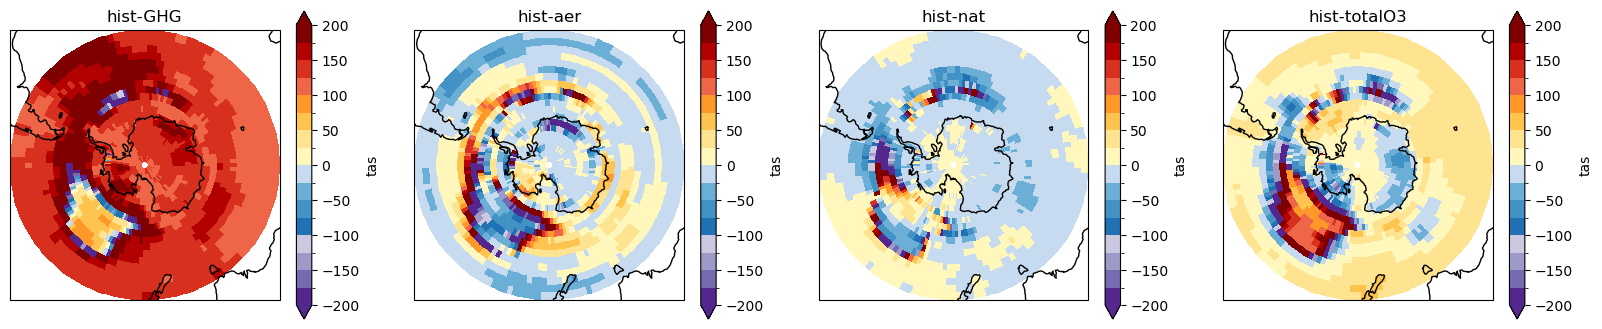

In [132]:
fig = plt.figure(figsize=(20, 4))

for i, exp in enumerate(fraction_of_historical.experiment.values):
    ax = fig.add_subplot(1, 4, i+1, projection=ccrs.SouthPolarStereo())


    (fraction_of_historical.sel(model=model, experiment=exp).isel(year=-1, season=0)*100).plot(
        ax=ax, robust=True, transform=ccrs.PlateCarree(), cmap=my_cmap, norm=my_norm, extend='both')
    ax.coastlines()
    ax.set_title(exp)

In [133]:
# sum_all_but_historical[model].sel(**latlon).isel(season=0).tas.plot(label='All but hist')

# lesfmip_tree_change_quantile[model].tas.sel(**latlon).isel(season=0).sel(quantile=0.5).plot(hue='experiment')

In [135]:
test_initial = xarray_datatree_utils.to_dataset(
    lesfmip_tree['HadGEM3-GC31-LL'].isel(lat=0, lon=20), concat_dim='experiment').compute()

In [136]:
test_initial = test_initial.resample(time='YE').mean().rolling(time=11, center=True).mean()

In [137]:
test_initial

<xarray.DataArray 'tas' (experiment: 5, time: 165, member: 60)> Size: 198kB
nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
Coordinates:
  * member      (member) object 480B 'r10i1p1f3' 'r11i1p1f3' ... 'r9i1p1f3'
    lat         float64 8B -87.5
    lon         float64 8B -130.0
    height      float64 8B 1.5
  * experiment  (experiment) <U12 240B 'hist-GHG' 'hist-aer' ... 'historical'
  * time        (time) object 1kB 1850-12-30 00:00:00 ... 2014-12-30 00:00:00

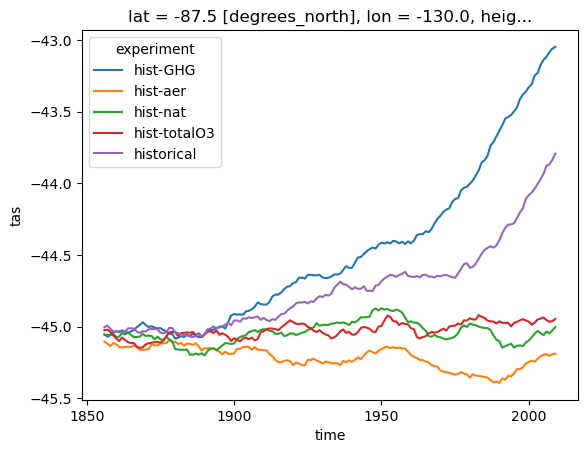

In [138]:
test_initial.isel(time=slice(11//2, -11//2)).mean(dim='member').plot(hue='experiment');

In [142]:
# xarray_datatree_utils.to_dataset(lesfmip_tree['CanESM5'].isel(lat=0, lon=0, member=0)).plot(hue='experiment');

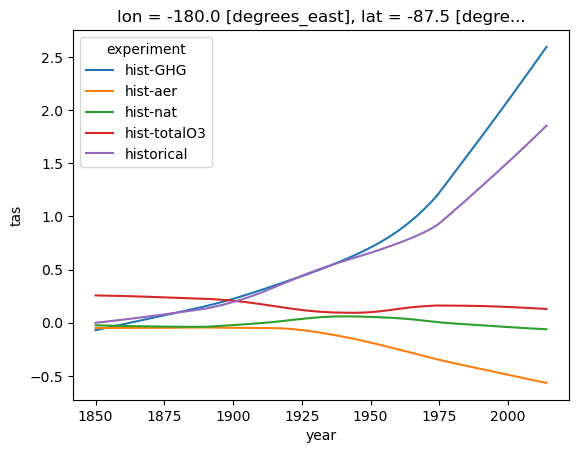

In [140]:
lesfmip_tree_change_quantile['CanESM5'].isel(season=0, lat=0, lon=0).sel(quantile=0.5).tas.plot(hue='experiment');

In [141]:
# ttree_rolling_q_smean_anom = ttree_rolling_q_smean - ttree_rolling_q_smean.isel(year=0)

In [ ]:
# quant_diff = ttree_rolling_q_smean.sel(quantile=0.9, method='nearest') - ttree_rolling_q_smean.sel(quantile=0.1, method='nearest')

## Smoothing Drafts

In [ ]:
def lanczos_weights(window, cutoff):
    """Lanczos low-pass filter weights, normalised to unit sum.

    Args:
        window (int): Filter width in timesteps, odd.
        cutoff (float): Cutoff frequency in inverse timesteps.

    Returns:
        xr.DataArray: Weights along a "window" dimension.
    """
    n = (window - 1) // 2 + 1
    k = np.arange(1.0, n)
    sigma = np.sin(np.pi * k / n) * n / (np.pi * k)
    sinc = np.sin(2 * np.pi * cutoff * k) / (np.pi * k)
    w = np.zeros(2 * n + 1)
    w[n] = 2 * cutoff
    w[n - 1 : 0 : -1] = sinc * sigma
    w[n + 1 : -1] = sinc * sigma
    w = w[1:-1]
    return xr.DataArray(w / w.sum(), dims="window")

In [ ]:
latlon = dict(lat=-81.88, lon=120.9, method='nearest')

In [ ]:
LACONZ_WINDOW = 31
LOCONZ_CUTOFF = 1. /20

laconz_weights = lanczos_weights(LACONZ_WINDOW, LOCONZ_CUTOFF)

In [ ]:
windows = lesfmip_tree_smooth_q['CanESM5']['historical'].sel(**latlon).isel(season=0).tas.rolling(year=31, center=True).construct('window')

In [ ]:
smooth = (windows * laconz_weights).sum('window', skipna=False)

In [ ]:
smooth

In [ ]:
lesfmip_tree_rolling_q['CanESM5']['historical'].sel(**latlon).isel(season=0).isel(year=slice(11//2+1, -11//2-1)).tas.plot(hue='quantile');
lesfmip_tree_smooth_q['CanESM5']['historical'].sel(**latlon).isel(season=0).isel(year=slice(11//2+1, -11//2-1)).tas.plot(hue='quantile', linestyle=':', color='grey', linewidth=3);

smooth.plot(hue='quantile', color='k', linestyle='--', add_legend=False);

In [ ]:
# %%time
# lesfmip_tree_smooth_member_q = lesfmip_tree_rolling_member_q.map_over_datasets(lowess_matrix_xarray).compute()

In [ ]:
# lesfmip_tree_smooth_member_q['historical'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='blue', add_legend=False);

# lesfmip_tree_smooth_member_q['hist-nat'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='grey', alpha=0.5, add_legend=False);
# # lesfmip_tree_rolling_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(color='k')

In [ ]:
# lesfmip_tree_rolling_member_q['historical'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='blue', add_legend=False);

# lesfmip_tree_rolling_member_q['hist-nat'].tas.sel(quantile=0.5).sel(**latlon).isel(season=0).plot(
#     hue='member', color='grey', alpha=0.5, add_legend=False);
# # lesfmip_tree_rolling_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(color='k')

In [ ]:
# %%time
#(t): The quantiles of the base period
# q_histnat_base_tree = lesfmip_tree['hist-nat']

In [ ]:
# %%time
# xr.DataTree.from_dict(
#     {exp: lesfmip_tree["CanESM5"][exp] for exp in ["hist-GHG", "historical"]}
# ).chunk({'time': -1, 'member': -1, 'lat': 2, 'lon': -1}).map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES)
# ).compute()

In [ ]:
# %%time
# rolling_season_quantile(lesfmip_tree[sorted_model_experiments[0]].xarray_datatree_utils.to_dataset().chunk({'time': -1, 'member': -1, 'lat': 2, 'lon': -1}), quantiles=QUANTILES).compute()

In [ ]:
# # lat has a size of 20

# for lat_size in [2, 4, 5]:
#     print(f' -- {lat_size=}')
#     chunks = {'time': -1, 'member': -1, 'lat': lat_size, 'lon': -1}
#     da = lesfmip_tree[sorted_model_experiments[-5]].xarray_datatree_utils.to_dataset().chunk(chunks)
#     print(coord_info(da))
#     t1 = time.time()
#     rolling_season_quantile(lesfmip_tree[sorted_model_experiments[0]].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()
#     time_taken = time.time() - t1
#     print(f'{time_taken:.2f}s')
#     print('\n')

In [ ]:
# lat_size=4

In [ ]:
# for model_exp in sorted_model_experiments:
#     print(f' - {model_exp}: ', end='')
#     t1 = time.time()
#     rolling_season_quantile(lesfmip_tree[model_exp].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()
#     time_taken = time.time() - t1
#     print(f'{time_taken}s')

In [ ]:
# %%time
# rolling_season_quantile(lesfmip_tree['CanESM5/hist-totalO3'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES).compute()

In [ ]:
# %%time
# lesfmip_tree_rolling_member_q = lesfmip_tree.map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES)
# ).compute()

In [ ]:
# %%time
# lesfmip_tree_rolling_member_q_da = rolling_season_quantile(lesfmip_tree['CanESM5']['historical']['tas'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES, extra_dimensions=[]).compute()

In [ ]:
# lesfmip_tree_rolling_member_q = rolling_season_quantile(lesfmip_tree['CanESM5']['historical']['tas'].xarray_datatree_utils.to_dataset(), quantiles=QUANTILES, extra_dimensions=[]).compute()

In [ ]:
# lesfmip_tree_rolling_member_q['historical']['tas'].sel(quantile=0.5).sel(**latlon).isel(season=0).plot(hue='member', color='k', add_legend=False);

In [ ]:
# lesfmip_tree_rolling_q = subse_tree.map_over_datasets(
#     partial(rolling_season_quantile, quantiles=QUANTILES, extra_dimensions=['member'])
# ).compute()

In [ ]:
#(t) Slice incomplete windows
lesfmip_tree_rolling_q = lesfmip_tree_rolling_q.isel(year=slice(11//2+1, -11//2-1))

# Bootstrapping

## General

In [147]:
QUANTILE_PAIRS = {
    80: {"upper": 0.9, "lower": 0.1},
    90: {"upper": 0.95, "lower": 0.05},
    98: {"upper": 0.99, "lower": 0.01},
}


def quantile_ranges(da, pairs=QUANTILE_PAIRS, dim="qrange"):
    """Compute the spread between symmetric quantile pairs.
    Parameters
    ----------
    da : xarray.DataArray
        Array with a `quantile` dimension containing the required levels.
    pairs : dict, optional
        Mapping of range label to a dict with `upper` and `lower` quantiles.
    dim : str, optional
        Name of the new dimension holding the range labels.
    Returns
    -------
    xarray.DataArray
        Ranges stacked along `dim`, with `quantile` removed.
    """
    ranges = []
    for label, cfg in pairs.items():
        upper = da.sel(quantile=cfg["upper"])
        lower = da.sel(quantile=cfg["lower"])
        ranges.append(upper - lower)
    return xr.concat(ranges, dim=xr.DataArray(list(pairs), dims=dim, name=dim))

In [148]:
QUANTILES

array([0.01, 0.05, 0.1 , 0.5 , 0.9 , 0.95, 0.99])

In [149]:
PLOT_QUANTILES

[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

In [150]:
rng = np.random.default_rng()

## All

In [151]:
tda = lesfmip_tree['MIROC6']['historical'].tas#.isel(lat=slice(0, 5), lon=slice(0, 5))#.sel(**latlon).tas
tda = tda.sel(time=tda.time.dt.month==12) # Is seasonal, so this is summer not December
tda.sizes

Frozen({'time': 164, 'member': 50, 'lat': 20, 'lon': 144})

In [152]:
# Only need last 11 years, not entire rolling
tda = tda.isel(time=slice(-21, None))

In [153]:
# tda_histnat = lesfmip_tree['MIROC6']['hist-nat'].tas.isel(lat=slice(0, 5), lon=slice(0, 5))#.sel(**latlon).tas
# tda_histnat = tda_histnat.sel(time=tda_histnat.time.dt.month==12)

In [154]:
n_samples = 10
n_trials = 10000
# random_indexes = np.random.randint(0, tda.sizes['member'], (n_trials, n_samples))
random_indexes = np.argsort(rng.random((n_trials, tda.sizes['member'])), axis=1)[:, :n_samples]
# random_indexes[:3]
random_indexes.shape

(10000, 10)

In [155]:
idx_da = xr.DataArray(random_indexes, dims=('trial', 'member'))

In [156]:
random_member_da = tda.isel(member=idx_da)

In [157]:
da_q = tda.quantile(QUANTILES, dim=['time', 'member']).compute()

In [158]:
da_random_q = random_member_da.quantile(QUANTILES, dim=['time', 'member']).compute()

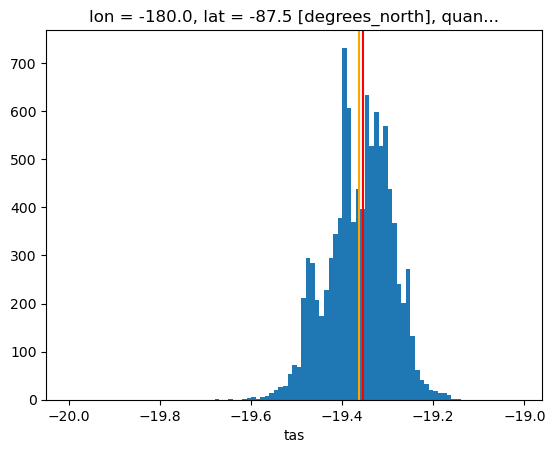

In [159]:
fig, ax = plt.subplots()
bins = np.arange(-20, -19, 0.01)
da_random_q.isel(lat=0, lon=0).sel(quantile=0.5).plot.hist(ax=ax, bins=bins);
ax.axvline(da_q.isel(lat=0, lon=0).sel(quantile=0.5).values.item(), color='red')
ax.axvline(da_random_q.isel(lat=0, lon=0).sel(quantile=0.5).mean(dim='trial').values.item(), color='orange')

In [160]:
da_random_q

<xarray.DataArray 'tas' (quantile: 7, trial: 10000, lat: 20, lon: 144)> Size: 2GB
-21.58 -21.41 -21.16 -20.92 -20.68 -20.47 ... 18.34 18.89 19.94 20.93 21.16
Coordinates:
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
Dimensions without coordinates: trial

In [161]:
random_mean = da_random_q.mean(dim='trial')
random_std = da_random_q.std(dim='trial')

In [162]:
cohens_d = (da_q - random_mean) / random_std
cohens_d

<xarray.DataArray 'tas' (quantile: 7, lat: 20, lon: 144)> Size: 161kB
-0.2673 -0.3244 -0.3193 -0.3322 -0.3073 ... 0.4386 0.517 0.7254 -0.00512 0.202
Coordinates:
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99

In [163]:
da_random_q

<xarray.DataArray 'tas' (quantile: 7, trial: 10000, lat: 20, lon: 144)> Size: 2GB
-21.58 -21.41 -21.16 -20.92 -20.68 -20.47 ... 18.34 18.89 19.94 20.93 21.16
Coordinates:
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
Dimensions without coordinates: trial

In [164]:
# Quantile ranges (e.g. the 90th - 10th percentile)
da_random_q_range_q = quantile_ranges(da_random_q)
da_q_range_q = quantile_ranges(da_q)

# Calculate the percent uncertainty
percent_range_q_std = da_random_q_range_q.std(dim='trial')
# Convert to percent, then  multiple by 2 for twice standard deviation
percent_range_q_uncertainty_percent = 100 * (2 * percent_range_q_std) / da_q_range_q
# percent_range_q_uncertainty = percent_range_q_uncertainty*2

In [165]:
da_q_range_q

<xarray.DataArray 'tas' (qrange: 3, lat: 20, lon: 144)> Size: 69kB
2.237 2.246 2.216 2.211 2.207 2.205 ... 2.744 2.986 3.562 3.735 3.317 2.736
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * qrange   (qrange) int64 24B 80 90 98

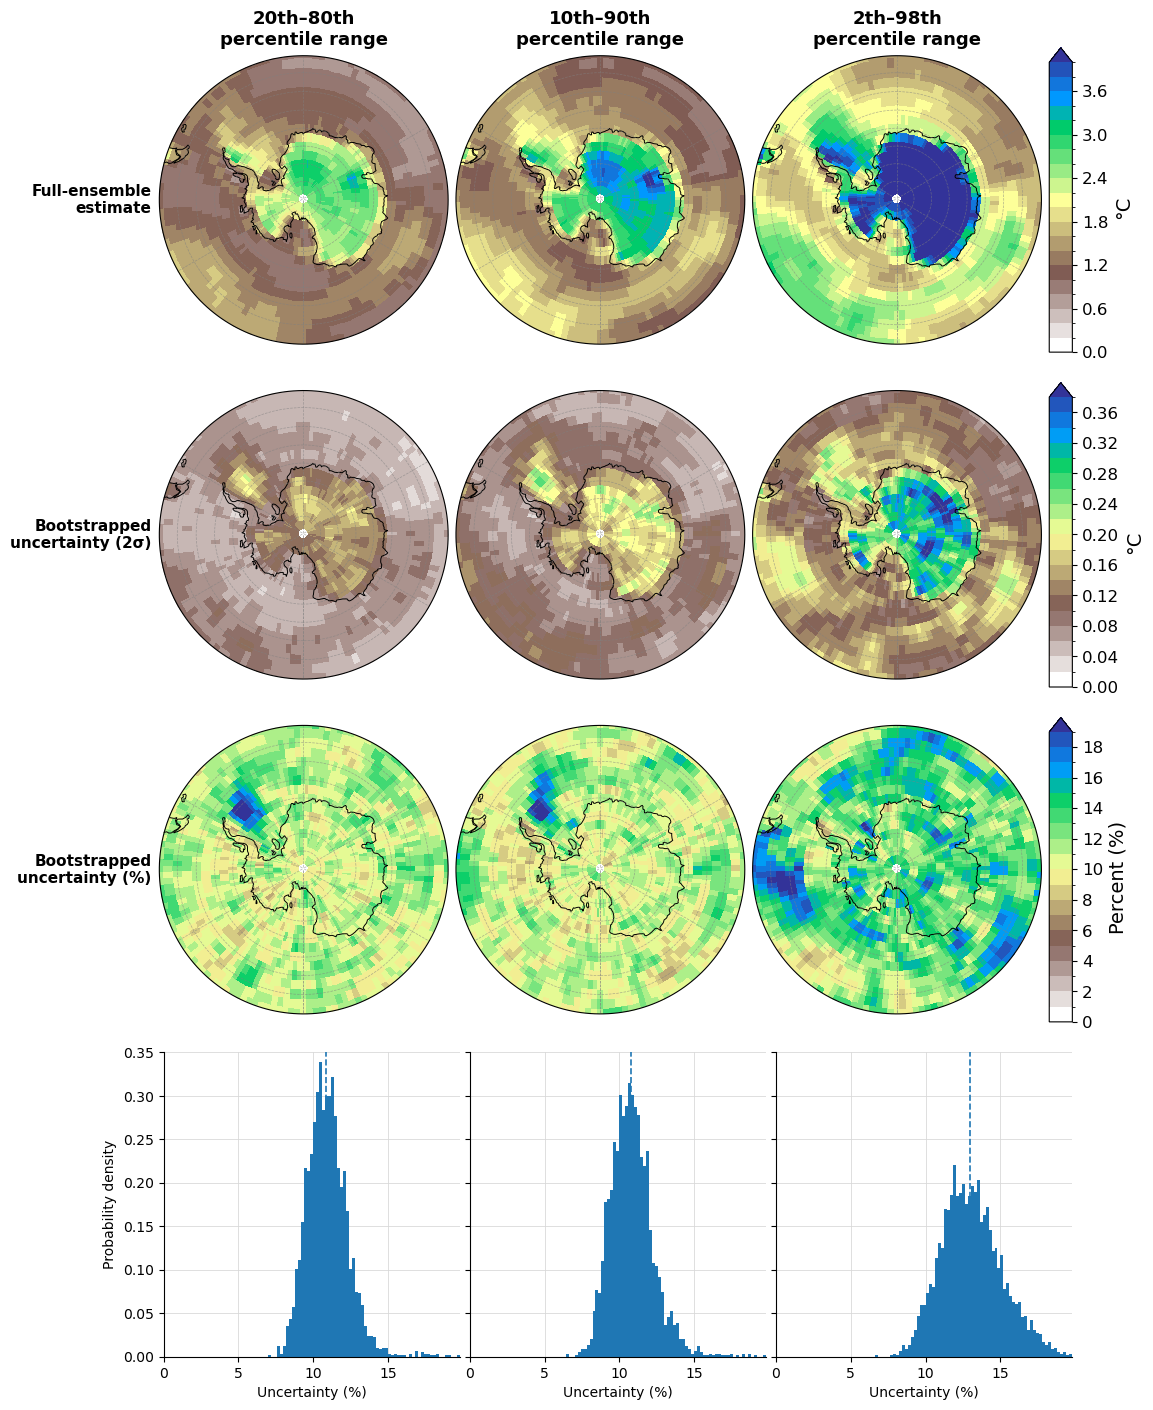

In [264]:
fig = plt.figure(figsize=(13, 17))

outer_gs = fig.add_gridspec(4, 1, hspace=0.1)

row_labels = [
    'Full-ensemble\nestimate',
    'Bootstrapped\nuncertainty (2σ)',
    'Bootstrapped\nuncertainty (%)',
    ''
]

axes_maps = []
caxes = []

for row in range(3):
    gs = outer_gs[row].subgridspec(
        # 2, 4,
        1, 5,
        # width_ratios=[0.9, 3, 3, 3], height_ratios=[1, 0.08],
        width_ratios=[0.9, 3, 3, 3, 0.24],
        # height_ratios=[1, 0.08],
        hspace=0.08, wspace=0.04)

    label_ax = fig.add_subplot(gs[0, 0])
    label_ax.axis('off')
    label_ax.text(1, 0.5, row_labels[row], ha='right', va='center', fontsize=11, fontweight='bold')

    # 0, i
    axes = [fig.add_subplot(gs[0, i], projection=ccrs.SouthPolarStereo()) for i in range(1, 4)]
    cax = fig.add_subplot(gs[-1])
    # cax = fig.add_subplot(gs[1, 1:])

    axes_maps.append(axes)
    caxes.append(cax)

gs = outer_gs[3].subgridspec(1, 4, width_ratios=[0.9, 3, 3, 3], wspace=0.04)

label_ax = fig.add_subplot(gs[0, 0])
label_ax.axis('off')
label_ax.text(1, 0.5, row_labels[3], ha='right', va='center', fontsize=11, fontweight='bold')

axes_hists = [fig.add_subplot(gs[0, i]) for i in range(1, 4)]


for i, qrange in enumerate(percent_range_q_uncertainty_percent.qrange):
    axn1 = axes_maps[0][i]
    ax0 = axes_maps[1][i]
    ax1 = axes_maps[2][i]
    ax2 = axes_hists[i]

    im0 = da_q_range_q.sel(qrange=qrange).plot(
        ax=axn1, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 4.2, .2), cmap='terrain_r',
        add_colorbar=False
    )

    im1 = percent_range_q_std.sel(qrange=qrange).plot(
        ax=ax0, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 0.4, 0.02), cmap='terrain_r',
        add_colorbar=False
    )

    im2 = percent_range_q_uncertainty_percent.sel(qrange=qrange).plot(
        ax=ax1, transform=ccrs.PlateCarree(),
        levels=np.arange(0, 20, 1), cmap='terrain_r',
        add_colorbar=False
    )

    values = percent_range_q_uncertainty_percent.sel(qrange=qrange).values.flatten()
    values = values[np.isfinite(values)]

    ax2.hist(values, bins=np.arange(0, 20, .2), density=True)
    ax2.axvline(np.median(values), linestyle='--', linewidth=1.2)
    ax2.set_xlim(0, 20)
    ax2.set_xlabel('Uncertainty (%)')
    ax2.set_ylabel('Probability density')

    maps.setup_polar_ax(axn1)
    maps.setup_polar_ax(ax0)
    maps.setup_polar_ax(ax1)

    axn1.set_title(f'{100 - qrange.values:.0f}th–{qrange.values:.0f}th\npercentile range', fontsize=13, fontweight='bold', pad=8)

    ax0.set_title('')
    ax1.set_title('')
    ax2.set_title('')

cbar_fontsize = 14
cbar_orientation = 'vertical'
cbar0 = fig.colorbar(im0, cax=caxes[0], orientation=cbar_orientation)
cbar0.set_label('°C', fontsize=cbar_fontsize)

cbar1 = fig.colorbar(im1, cax=caxes[1], orientation=cbar_orientation)
cbar1.set_label('°C', fontsize=cbar_fontsize)

cbar2 = fig.colorbar(im2, cax=caxes[2], orientation=cbar_orientation)
cbar2.set_label('Percent (%)', fontsize=cbar_fontsize)

for cbar in [cbar0, cbar1, cbar2]: cbar.ax.tick_params(labelsize=12)

for j, ax in enumerate(axes_hists):
    if j > 0: ax.set_ylabel(''); ax.set_yticklabels([])
    formatting.style_ax(ax)
    ax.set_ylim(0, 0.35)

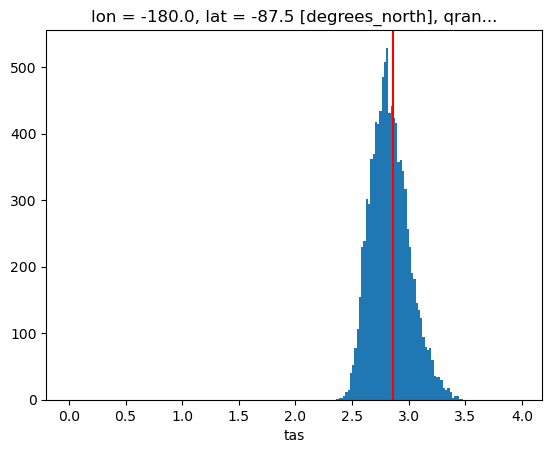

In [238]:
fig, ax = plt.subplots()
bins = np.arange(0, 4, 0.02)
da_random_q_range_q.sel(qrange=90).isel(lat=0, lon=0).plot.hist(bins=bins);
ax.axvline(da_q_range_q.sel(qrange=90).isel(lat=0, lon=0).values.item(), color='red')

## Example

In [ ]:
tda = lesfmip_tree['MIROC6']['historical'].tas.sel(**latlon)
tda = tda.sel(time=tda.time.dt.month==12)
tda.sizes

In [ ]:
tda_histnat = lesfmip_tree['MIROC6']['hist-nat'].tas.sel(**latlon)
tda_histnat = tda_histnat.sel(time=tda_histnat.time.dt.month==12)

In [ ]:
n_samples = 10
n_trials = 10000
# random_indexes = np.random.randint(0, tda.sizes['member'], (n_trials, n_samples))
random_indexes = np.argsort(rng.random((n_trials, tda.sizes['member'])), axis=1)[:, :n_samples]
# random_indexes[:3]
random_indexes.shape

In [ ]:
idx_da = xr.DataArray(random_indexes, dims=('trial', 'member'))

In [ ]:
idx_da

In [ ]:
random_member_histnat = tda_histnat.isel(member=idx_da)

In [ ]:
random_member_da = tda.isel(member=idx_da)

In [ ]:
random_member_da_q = random_member_da.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
da_q = tda.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
da_histnat_q = random_member_histnat.quantile(QUANTILES, dim=['time', 'member']).compute()

In [ ]:
random_member_da_rolling_q = (random_member_da
    .rolling(time=11, center=True)
    .construct("window")
    .quantile(QUANTILES, dim=['window', 'member'])
    .compute()
                             )

In [ ]:
%%time
da_rolling_q = (tda
    .rolling(time=11, center=True)
    .construct("window")
    .quantile(QUANTILES, dim=['window', 'member'])
    .compute()
                             )

In [ ]:
#da_histnat_q

In [ ]:
random_member_da_q.std(dim='trial').to_pandas()

In [ ]:
np.abs(100*random_member_da_q.std(dim='trial')/da_q).to_pandas()

In [ ]:
#(t): Signal to noise 
random_base_std = random_member_da.sel(time=slice('1850', '1900')).std(dim=['time', 'member']).compute()
random_base_std_histnat = tda_histnat.std(dim=['time', 'member']).compute()
random_base_mean = random_member_da.sel(time=slice('1850', '1900')).mean(dim=['time', 'member']).compute()

random_signal = (random_member_da - random_base_mean).rolling(time=11, center=True).mean().mean(dim='member').compute()
random_sn = random_signal/random_base_std
random_sn_histnat = random_signal/random_base_std_histnat

In [ ]:
random_sn.isel(trial=1).plot()
random_sn_histnat.isel(trial=1).plot()

In [ ]:
QUANTILE_PAIRS = {
    80: {"upper": 0.9, "lower": 0.1},
    90: {"upper": 0.95, "lower": 0.05},
    98: {"upper": 0.99, "lower": 0.01},
}


def quantile_ranges(da, pairs=QUANTILE_PAIRS, dim="qrange"):
    """Compute the spread between symmetric quantile pairs.
    Parameters
    ----------
    da : xarray.DataArray
        Array with a `quantile` dimension containing the required levels.
    pairs : dict, optional
        Mapping of range label to a dict with `upper` and `lower` quantiles.
    dim : str, optional
        Name of the new dimension holding the range labels.
    Returns
    -------
    xarray.DataArray
        Ranges stacked along `dim`, with `quantile` removed.
    """
    ranges = []
    for label, cfg in pairs.items():
        upper = da.sel(quantile=cfg["upper"])
        lower = da.sel(quantile=cfg["lower"])
        ranges.append(upper - lower)
    return xr.concat(ranges, dim=xr.DataArray(list(pairs), dims=dim, name=dim))

In [ ]:
da_q_rolling_q_range = quantile_ranges(da_rolling_q, QUANTILE_PAIRS)

In [ ]:
random_q_rolling_q_range = quantile_ranges(random_member_da_rolling_q, QUANTILE_PAIRS)

In [ ]:
# da_q_rolling_q_range = da_rolling_q.sel(quantile=0.9) - da_rolling_q.sel(quantile=0.1)

In [ ]:
random_q_rolling_q_range

In [ ]:
list(random_q_rolling_q_range.qrange.values)

In [ ]:
qrange = 90
random_q_rolling_q_range.sel(qrange=qrange).plot(hue='trial', color='grey', add_legend=False);
da_q_rolling_q_range.sel(qrange=qrange).plot()

In [ ]:
qrange = 80
random_q_rolling_q_range.sel(qrange=qrange).plot(hue='trial', color='grey', add_legend=False);
da_q_rolling_q_range.sel(qrange=qrange).plot()

In [ ]:
random_q_rolling_q_range.std(dim='trial').plot()
da_q_rolling_q_range.plot()

In [ ]:
random_sn_plot_quantiles =\
   random_sn.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_sn_histnat_plot_quantiles =\
   random_sn_histnat.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_signal_plot_quantiles =\
   random_signal.quantile(
       PLOT_QUANTILES, dim='trial').compute()

In [ ]:
random_member_q_diff_plot_quantiles =\
   random_member_da_rolling_q.rename({'quantile': 'quantile_trial'}).quantile(
       PLOT_QUANTILES, dim='trial')

In [ ]:
random_member_da_rolling_q_plot_quantiles =\
   random_member_da_rolling_q.rename({'quantile': 'quantile_trial'}).quantile(
       PLOT_QUANTILES, dim='trial')

In [ ]:
plot_quantile_selection = [0.01, 0.25, 0.75, 0.99]

In [ ]:
from matplotlib.patches import Patch


In [ ]:

colors = plt.cm.viridis(np.linspace(0, 1, len(random_member_da_rolling_q_plot_quantiles.quantile_trial)))

fig, ax1 = plt.subplots()
for qt, color in zip(random_member_da_rolling_q_plot_quantiles.quantile_trial.values[:-1], colors):
    plot_fan(ax1, random_member_da_rolling_q_plot_quantiles.sel(quantile_trial=qt),
             quantiles=plot_quantile_selection, color=color, label=f"{qt:.2f}",
             band_labels=False, x_dim='time')

levels = sorted(set(plot_quantile_selection) | {0.5})
rings = _ring_index(levels, 0.5)
ring_alphas = np.linspace(0.6, 0.15, max(rings) + 1)
band_handles = [Patch(facecolor="0.3", alpha=ring_alphas[ring],
                       label=f"{levels[i]:.0%}\u2013{levels[i+1]:.0%}")
                for i, ring in enumerate(rings)]

ax1.set_title("Bootstrapped quantiles", fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature " + r'($^\circ$C)')

leg_bands = ax1.legend(handles=band_handles, title="Uncertainty range", loc="upper left")
ax1.add_artist(leg_bands)
ax1.legend(title="Quantile", loc="upper center", ncol=2)

formatting.style_ax(ax1, scale=1.2)
fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(2, 3)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[1, :2])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 2])


plot_fan(ax1, random_signal_plot_quantiles , quantiles=plot_quantile_selection, color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_sn_plot_quantiles, quantiles=plot_quantile_selection, color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Signal")
ax2.set_title("S/N ratio")

ax2.set_ylabel("S/N ratio")
ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax1.legend()

random_base_std.plot.hist(ax=ax3, color="0.5", edgecolor="white")
ax3.set_title("Base Period Noise")

random_base_mean.plot.hist(ax=ax4, color="0.5", edgecolor="white")
ax4.set_title("Base Period Mean")

ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax3.set_xlabel("Noise " + r"($^\circ$C)")
ax4.set_xlabel("Mean " + r"($^\circ$C)")


for ax in [ax1, ax2, ax3, ax4]: formatting.style_ax(ax, scale=1.2)

fig.suptitle(formatting.format_sel({k: v for k, v in latlon.items() if k != 'method'}), fontsize=14, fontweight='bold')

fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(3, 1)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])


plot_fan(ax1, random_sn_histnat_plot_quantiles , quantiles=plot_quantile_selection, 
         color="C0", label="Median", band_labels=True, x_dim='time')

plot_fan(ax2, random_sn_plot_quantiles, quantiles=plot_quantile_selection,
         color="C1", label="Median", band_labels=True, x_dim='time')

plot_fan(ax3, random_sn_histnat_plot_quantiles-random_sn_plot_quantiles, quantiles=plot_quantile_selection,
         color="C3", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Signal")
ax2.set_title("S/N ratio")
ax2.set_title("Difference")

ax2.set_ylabel("S/N ratio")
ax1.set_ylabel("Signal " + r"($^\circ$C)")
ax1.legend()

ax1.set_ylabel("Signal " + r"($^\circ$C)")



for ax in [ax1, ax2, ax3]: formatting.style_ax(ax, scale=1.2)

fig.suptitle(formatting.format_sel({k: v for k, v in latlon.items() if k != 'method'}), fontsize=14, fontweight='bold')

fig.tight_layout()

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 11))

plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_signal_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("S/N ratio")
ax2.set_title("Signal")
ax1.legend()

for ax in [ax1, ax2]: formatting.style_ax(ax)

random_base_mean.plot.hist(ax=ax3, color="0.5", edgecolor="white")
ax3.set_title("Base period distribution")

fig.tight_layout()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1)
plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C0", label="Median", band_labels=True, x_dim='time')
plot_fan(ax2, random_signal_plot_quantiles, quantiles=[0.1, 0.25, 0.75, 0.9], color="C1", label="Median", band_labels=True, x_dim='time')
ax1.set_title("Model A")
ax2.set_title("Model B")
ax1.legend()
# ax2.legend()

In [ ]:
random_base_mean.plot.hist()

In [ ]:
fig, ax1 = plt.subplots()
plot_fan(ax1, random_sn_plot_quantiles, quantiles=[0.01, 0.25, 0.5, 0.75, 0.99], color="C0", label="Median", band_labels=True, x_dim='time')


In [ ]:
np.abs(100*random_member_da_rolling_q.std(dim='trial')/da_rolling_q).plot(hue='quantile');

In [ ]:
random_member_da_rolling_q.std(dim='trial').plot(hue='quantile');

# Plotting

In [ ]:
from matplotlib.lines import Line2D
import string
from cartopy.util import add_cyclic_point

In [ ]:


FORCING_REVEAL_ORDER = ["hist-nat", "hist-GHG", "hist-aer", "hist-totalO3", "historical"]

FORCING_COLORS = {
    "hist-nat": "#2E8B57",
    "hist-GHG": "#D1495B",
    "hist-aer": "#3A86C8",
    "hist-totalO3": "#8A5FBF",
    "historical": "#1A1A1A",
}

FORCING_LEGEND_LABELS = {
    "hist-nat": "hist-nat (natural only)",
    "hist-GHG": "hist-GHG (greenhouse gases)",
    "hist-aer": "hist-aer (aerosols)",
    "hist-totalO3": "hist-totalO3 (ozone)",
    "historical": "historical (all forcings)",
}

BUILDUP_SLIDE_RC = {
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0,
    "lines.solid_capstyle": "round",
    "savefig.dpi": 200,
}

BUILDUP_FRAME_DIR = Path("slides_tas_buildup")
BUILDUP_FRAME_DIR.mkdir(parents=True, exist_ok=True)
BUILDUP_FRAME_SIZE = (9, 5)

In [ ]:
buildup_annual_tas = {}
for forcing in FORCING_REVEAL_ORDER:
    annual_tas = (lesfmip_tree["CanESM5"][forcing].tas
        .sel(**latlon)
        .resample(time="YE").mean()
        .isel(time=slice(None, -1))
        .load()
                 ) -273.15
    buildup_annual_tas[forcing] = annual_tas.assign_coords(year=annual_tas.time.dt.year).swap_dims(time="year")

buildup_single_member_tas = {k: v.isel(member=0) for k, v in buildup_annual_tas.items()}
buildup_ensemble_mean_tas = {k: v.mean(dim="member") for k, v in buildup_annual_tas.items()}

buildup_single_member_values = np.concatenate([v.values.ravel() for v in buildup_single_member_tas.values()])
BUILDUP_YLIM_SPREAD = (
    np.nanmin(buildup_single_member_values) - 0.3,
    np.nanmax(buildup_single_member_values) + 0.3,
)

buildup_ensemble_mean_values = np.concatenate([v.values.ravel() for v in buildup_ensemble_mean_tas.values()])
BUILDUP_YLIM_MEAN = (
    np.nanmin(buildup_ensemble_mean_values) - 0.2,
    np.nanmax(buildup_ensemble_mean_values) + 0.2,
)

buildup_all_years = np.concatenate([v.year.values for v in buildup_annual_tas.values()])
BUILDUP_XLIM = (buildup_all_years.min() - 2, buildup_all_years.max() + 2)

BUILDUP_BASELINE_TAS = float(buildup_ensemble_mean_tas["hist-nat"].sel(year=slice(1850, 1900)).mean())

In [ ]:
def style_buildup_axis(ax, ylim):
    """Apply shared frame styling so every saved buildup frame lines up exactly.

    Args:
        ax (Axes): Axis to style.
        ylim (tuple): Lower and upper y limits.
    """
    ax.axhline(BUILDUP_BASELINE_TAS, color="0.75", lw=0.9, ls=(0, (4, 3)), zorder=0)
    ax.set_xlim(*BUILDUP_XLIM)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Year")
    ax.set_ylabel("Near-surface air temperature [K]")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=4, width=1.0)


def draw_buildup_series(ax, tas_by_forcing, revealed_forcings, fade_earlier):
    """Draw one line per forcing in reveal order.

    Args:
        ax (Axes): Axis to draw on.
        tas_by_forcing (dict): Forcing name to DataArray with a `year` dimension.
        revealed_forcings (list): Forcings to draw, in reveal order.
        fade_earlier (bool): Dim all but the newest line.
    """
    for position, forcing in enumerate(revealed_forcings):
        is_newest = position == len(revealed_forcings) - 1
        ax.plot(
            tas_by_forcing[forcing].year,
            tas_by_forcing[forcing],
            color=FORCING_COLORS[forcing],
            lw=2.2 if is_newest else 1.5,
            alpha=0.35 if fade_earlier and not is_newest else 1.0,
            zorder=3 + position,
        )


def add_buildup_legend(fig, revealed_forcings):
    """Add the full legend with unrevealed entries dimmed, keeping geometry fixed.

    Args:
        fig (Figure): Figure to attach the legend to.
        revealed_forcings (list): Forcings already drawn.
    """
    handles = [
        Line2D(
            [], [],
            color=FORCING_COLORS[forcing],
            lw=2.4,
            label=FORCING_LEGEND_LABELS[forcing],
            alpha=1.0 if forcing in revealed_forcings else 0.12,
        )
        for forcing in FORCING_REVEAL_ORDER
    ]
    buildup_legend = fig.legend(handles=handles, loc="outside upper center", ncols=3, frameon=False)
    for forcing, text in zip(FORCING_REVEAL_ORDER, buildup_legend.get_texts()):
        text.set_alpha(1.0 if forcing in revealed_forcings else 0.22)


def save_buildup_frame(fig, frame_number, frame_name):
    """Write a frame at fixed canvas size and close it.

    Args:
        fig (Figure): Figure to save.
        frame_number (int): Slide order index.
        frame_name (str): Descriptive suffix for the filename.
    """
    fig.savefig(BUILDUP_FRAME_DIR / f"{frame_number:02d}_{frame_name}.png", facecolor="white")
    plt.close(fig)

In [ ]:
with plt.rc_context(BUILDUP_SLIDE_RC):
    for n_shown in range(1, len(FORCING_REVEAL_ORDER) + 1):
        revealed_forcings = FORCING_REVEAL_ORDER[:n_shown]
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        draw_buildup_series(
            ax,
            buildup_single_member_tas,
            revealed_forcings,
            fade_earlier=n_shown < len(FORCING_REVEAL_ORDER),
        )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, revealed_forcings)
        # save_buildup_frame(fig, n_shown, f"single_{revealed_forcings[-1]}")

In [ ]:
buildup_historical_members = buildup_annual_tas["historical"].transpose("year", "member")

with plt.rc_context(BUILDUP_SLIDE_RC):
    for step, show_ensemble_mean in enumerate([False, True]):
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        ax.plot(
            buildup_historical_members.year,
            buildup_historical_members.values,
            color=FORCING_COLORS["historical"],
            lw=0.6,
            alpha=0.25,
            zorder=2,
        )
        if show_ensemble_mean:
            ax.plot(
                buildup_ensemble_mean_tas["historical"].year,
                buildup_ensemble_mean_tas["historical"],
                color=FORCING_COLORS["historical"],
                lw=2.6,
                zorder=4,
            )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, ["historical"])
        # save_buildup_frame(
        #     fig,
        #     6 + step,
        #     "historical_mean" if show_ensemble_mean else "historical_members",
        # )

In [ ]:
with plt.rc_context(BUILDUP_SLIDE_RC):
    for n_shown in range(1, len(FORCING_REVEAL_ORDER) + 1):
        revealed_forcings = FORCING_REVEAL_ORDER[:n_shown]
        fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
        draw_buildup_series(
            ax,
            buildup_ensemble_mean_tas,
            revealed_forcings,
            fade_earlier=n_shown < len(FORCING_REVEAL_ORDER),
        )
        style_buildup_axis(ax, BUILDUP_YLIM_SPREAD)
        add_buildup_legend(fig, revealed_forcings)
        save_buildup_frame(fig, 7 + n_shown, f"mean_{revealed_forcings[-1]}")

    fig, ax = plt.subplots(figsize=BUILDUP_FRAME_SIZE, layout="constrained")
    draw_buildup_series(ax, buildup_ensemble_mean_tas, FORCING_REVEAL_ORDER, fade_earlier=False)
    style_buildup_axis(ax, BUILDUP_YLIM_MEAN)
    add_buildup_legend(fig, FORCING_REVEAL_ORDER)
    # save_buildup_frame(fig, 13, "mean_zoom")

In [ ]:
# PAIRS = [(0.05, 0.95), (0.10, 0.90)]
# ALPHA = 0.18

# das = {exp: node.isel(season=0).squeeze(drop=True)
#        for exp, node in lesfmip_tree_smooth_q_smean['CanESM5'].items()}
# ref = das['tas'].sel(experiment='historical')

# ncols = 2
# nrows = int(np.ceil(len(das) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 2.6 * nrows),
#                          sharex=True, sharey=True, layout='constrained')
# axes = axes.ravel()
# for ax in axes[len(das):]:
#     fig.delaxes(ax)

# colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
# for ax, (exp, da), colour in zip(axes, das.items(), colours):
#     plotting_functions.plot_plume(ax, ref, PAIRS, color='0.55', alphas=0.10,
#                                   lw=1.0, x_dim='year')
#     plotting_functions.plot_plume(ax, da, PAIRS, color=colour, alphas=ALPHA,
#                                   label=exp, x_dim='year')
#     ax.set_title(exp, loc='left', fontweight='bold')
#     style_axis(ax)

# fig.supxlabel('year')
# fig.supylabel('tas anomaly (K)')

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import draft_current_plotting_functions as plotting_functions

In [ ]:
SEASON_COLORS = {
    'DJF': '#1f77b4',
    'MAM': '#2ca02c',
    'JJA': '#d62728',
    'SON': '#ff7f0e'
}


def plot_season_column(ax_diff, ax_main, da_point, season, color, q_pairs, q_med, is_first_col):
    """Plot difference spread for all quantile pairs on top panel 
    and nested 3-tier quantile plume on bottom panel."""
    
    da_season = da_point.sel(season=season)
    time_dim = 'year' if 'year' in da_season.coords else da_season.dims[0]
    time_coords = da_season.coords[time_dim].values.squeeze().ravel()
    
    # --- Top Subpanel: Delta Spread for ALL Quantile Pairs ---
    # Line styles & alphas for the spread lines in the top panel
    top_styles = ['-', '--', ':']
    top_alphas = [1.0, 0.75, 0.55]
    
    for idx, (q_low_val, q_high_val) in enumerate(q_pairs):
        q_low_s = da_season.sel(quantile=q_low_val, method='nearest')
        q_high_s = da_season.sel(quantile=q_high_val, method='nearest')
        spread_s = (q_high_s - q_low_s).values.squeeze().ravel()
        
        style = top_styles[idx % len(top_styles)]
        alpha = top_alphas[idx % len(top_alphas)]
        
        ax_diff.plot(
            time_coords, 
            spread_s, 
            color=color, 
            linestyle=style,
            alpha=alpha,
            linewidth=1.2,
            label=f'q{q_high_val}-q{q_low_val}' if is_first_col else None
        )
    
    ax_diff.set_title(season, fontsize=11, fontweight='bold', pad=4)
    ax_diff.set_xlabel('')
    ax_diff.tick_params(labelbottom=False, labelsize=8)
    ax_diff.grid(True, linestyle=':', alpha=0.5)
    
    if is_first_col:
        ax_diff.set_ylabel('Δ Quantiles', fontsize=9)
        ax_diff.legend(fontsize=7, loc='upper left', frameon=True, framealpha=0.8)
    else:
        ax_diff.set_ylabel('')

    # --- Bottom Subpanel: 3-Tier Plume ---
    # 3 distinct opacities and edge properties for all 3 pairs
    alphas = [0.08, 0.18, 0.32]
    edge_widths = [0.0, 0.6, 1.0]
    edge_styles = ['-', ':', '--']

    plotting_functions.plot_plume(
        ax=ax_main,
        da=da_season,
        pairs=q_pairs,
        median=q_med,
        color=color,
        alphas=alphas,
        edge_widths=edge_widths,
        edge_styles=edge_styles,
        edge_alpha=0.6,
        lw=1.8,
        label='Median' if is_first_col else None,
        x_dim=time_dim,
        quantile_dim='quantile'
    )
    
    ax_main.set_title('')
    ax_main.set_xlabel('Year', fontsize=9)
    ax_main.tick_params(labelsize=8)
    ax_main.grid(True, linestyle=':', alpha=0.5)
    
    if is_first_col:
        ax_main.set_ylabel('Difference (hist-nat - hist)', fontsize=9)
    else:
        ax_main.set_ylabel('')

    return alphas


def create_quantile_summary_figure(da_point, q_pairs=((0.01, 0.99), (0.1, 0.9), (0.25, 0.75)), q_med=0.5):
    """Generates 4-column layout with room at the bottom for a prominent figure legend."""
    
    seasons = da_point.season.values
    n_seasons = len(seasons)
    
    fig = plt.figure(figsize=(3.5 * n_seasons, 6.2), dpi=150)
    gs = GridSpec(
        nrows=2, 
        ncols=n_seasons, 
        height_ratios=[1, 2.2], 
        hspace=0.18, 
        wspace=0.25,
        bottom=0.14
    )
    
    alphas = []
    for i, season in enumerate(seasons):
        ax_diff = fig.add_subplot(gs[0, i])
        ax_main = fig.add_subplot(gs[1, i], sharex=ax_diff)
        
        color = SEASON_COLORS.get(season, f'C{i}')
        
        alphas = plot_season_column(
            ax_diff=ax_diff, 
            ax_main=ax_main, 
            da_point=da_point, 
            season=season, 
            color=color, 
            q_pairs=q_pairs,
            q_med=q_med,
            is_first_col=(i == 0)
        )

    # Global bottom legend setup
    first_ax = fig.axes[1]
    legend_obj = plotting_functions.plume_legend(
        ax=first_ax, 
        pairs=q_pairs, 
        alphas=alphas, 
        color="0.35"
    )
    
    handles, labels = first_ax.get_legend_handles_labels()
    first_ax.get_legend().remove()
    
    fig.legend(
        handles=handles, 
        labels=labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.01), 
        ncol=4, 
        fontsize=10, 
        frameon=True,
        facecolor='white',
        framealpha=0.95
    )

    return fig, gs

In [ ]:
# Execute figure generation
fig, gs = create_quantile_summary_figure(
    # da_rolling_q.isel(lat=0, lon=0), 
    lesfmip_tree_smooth_q['CanESM5']['historical'].tas.isel(lat=0, lon=0),
    q_pairs=((0.01, 0.99), (0.1, 0.9), (0.25, 0.75)), 
    q_med=0.5
)

plt.show()

In [ ]:
def antarctic_format(ax):
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    # circular boundary in axes coordinates
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.coastlines()

In [ ]:
final_change_quantile

In [ ]:
"""Polar quantile matrix figures with row-count-invariant layout."""

# --------------------------------------------------------------------------
# Layout constants, all in INCHES. Nothing here is a figure fraction, which
# is what keeps the colorbars identical whether there is 1 row or 10.
# --------------------------------------------------------------------------
PANEL_SIZE = 3.0  # side length of one square polar panel
WSPACE = 0.10  # gap between columns
HSPACE = 0.28  # gap between rows
MARGIN_LEFT = 1.00  # room for row labels
MARGIN_RIGHT = 0.15
MARGIN_TOP = 0.40  # room for column titles
TITLE_SPACE = 0.45  # extra top room when a suptitle is passed
CBAR_GAP = 0.45  # gap between the bottom row and the bars
CBAR_HEIGHT = 0.16  # bar thickness
CBAR_LABELS = 0.45  # room below the bars for tick labels
CBAR_TITLE = 0.24  # extra room below that for the colorbar axis label
CBAR_INSET = 0.30  # horizontal inset so bars stop short of the panel edges


class _Layout:
    """Convert a fixed inch-based layout into figure fractions.

    Parameters
    ----------
    n_rows : int
        Number of rows in the panel grid.
    n_cols : int
        Number of columns in the panel grid.
    has_title : bool
        Whether extra top margin is reserved for a suptitle.
    has_cbar_label : bool
        Whether extra bottom margin is reserved for colorbar axis labels.
    """

    def __init__(self, n_rows, n_cols, has_title=False, has_cbar_label=False):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.top_in = MARGIN_TOP + (TITLE_SPACE if has_title else 0.0)
        self.cbar_y0 = CBAR_LABELS + (CBAR_TITLE if has_cbar_label else 0.0)
        self.bottom_in = self.cbar_y0 + CBAR_HEIGHT + CBAR_GAP
        self.grid_w = n_cols * PANEL_SIZE + (n_cols - 1) * WSPACE
        self.grid_h = n_rows * PANEL_SIZE + (n_rows - 1) * HSPACE
        self.fig_w = MARGIN_LEFT + self.grid_w + MARGIN_RIGHT
        self.fig_h = self.top_in + self.grid_h + self.bottom_in

    def fx(self, inches):
        """Convert a horizontal length in inches to a figure fraction."""
        return inches / self.fig_w

    def fy(self, inches):
        """Convert a vertical length in inches to a figure fraction."""
        return inches / self.fig_h

    def make_figure(self):
        """Return a figure sized so each panel is exactly PANEL_SIZE inches."""
        return plt.figure(figsize=(self.fig_w, self.fig_h))

    def make_gridspec(self, fig):
        """Return a GridSpec pinned to absolute figure-edge offsets."""
        return GridSpec(
            self.n_rows,
            self.n_cols,
            figure=fig,
            left=self.fx(MARGIN_LEFT),
            right=self.fx(MARGIN_LEFT + self.grid_w),
            bottom=self.fy(self.bottom_in),
            top=self.fy(self.bottom_in + self.grid_h),
            wspace=WSPACE / PANEL_SIZE,
            hspace=HSPACE / PANEL_SIZE,
        )

    def col_left(self, col):
        """Return the left edge of a column in inches from the figure edge."""
        return MARGIN_LEFT + col * (PANEL_SIZE + WSPACE)

    def cbar_ax(self, fig, first_col, last_col, inset=CBAR_INSET):
        """Add a colorbar axes spanning columns first_col..last_col inclusive."""
        x0 = self.col_left(first_col) + inset
        x1 = self.col_left(last_col) + PANEL_SIZE - inset
        return fig.add_axes(
            [self.fx(x0), self.fy(self.cbar_y0), self.fx(x1 - x0), self.fy(CBAR_HEIGHT)]
        )

    def title_y(self):
        """Return the figure-fraction y for a top-aligned suptitle."""
        return self.fy(self.fig_h - 0.18)


def setup_polar_ax(ax, extent=(-180, 180, -90, -50)):
    """Apply circular boundary, coastlines and gridlines to a polar axes.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to configure, expected to use a polar stereographic projection.
    extent : sequence of float
        Extent as (lon_min, lon_max, lat_min, lat_max) in PlateCarree.
    """
    theta = np.linspace(0, 2 * np.pi, 200)
    circle_path = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)

    ax.set_aspect("equal", adjustable="box")
    ax.set_extent(list(extent), crs=ccrs.PlateCarree())
    ax.set_boundary(circle_path, transform=ax.transAxes)
    ax.coastlines(linewidth=0.7)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=0.5, color="gray", alpha=0.6, linestyle="--")
    gl.n_steps = 90
    return ax


def plot_polar_contour(ax, da, levels, cmap="RdBu_r", lat_name="lat", lon_name="lon"):
    """Filled and line contours of a 2-D field on a polar axes.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Target axes.
    da : xarray.DataArray
        Field with latitude and longitude dimensions.
    levels : array_like
        Contour levels.
    cmap : str
        Colormap name.
    lat_name : str
        Name of the latitude coordinate.
    lon_name : str
        Name of the longitude coordinate.
    """
    da = da.transpose(lat_name, lon_name)
    data_cyclic, lons_cyclic = add_cyclic_point(da.values, coord=da[lon_name].values)
    lats = da[lat_name].values

    cf = ax.contourf(
        lons_cyclic,
        lats,
        data_cyclic,
        transform=ccrs.PlateCarree(),
        levels=levels,
        cmap=cmap,
        extend="both",
    )
    ax.contour(
        lons_cyclic,
        lats,
        data_cyclic,
        transform=ccrs.PlateCarree(),
        levels=levels,
        colors="k",
        linewidths=0.3,
        alpha=0.5,
    )

    setup_polar_ax(ax)
    return cf


def plot_quantile_matrix(
    ds,
    row_dim="season",
    quant_dim="quantile",
    q_low=0.1,
    q_high=0.9,
    raw_levels=np.linspace(-3, 3, 13),
    diff_levels=np.linspace(-2, 2, 9),
    cmap="RdBu_r",
    lat_name="lat",
    lon_name="lon",
    title=None,
    raw_label=None,
    diff_label=None,
):
    """Grid of polar panels: low, median, high quantile and their difference.

    Panels are a fixed physical size and the colorbars are identical regardless
    of how many rows are drawn.

    Parameters
    ----------
    ds : xarray.DataArray
        Field with a quantile dimension and optionally a row dimension.
    row_dim : str
        Dimension mapped to figure rows.
    quant_dim : str
        Dimension holding the quantiles.
    q_low, q_high : float
        Quantiles drawn in the first and third columns.
    raw_levels : array_like
        Contour levels for the three quantile columns.
    diff_levels : array_like
        Contour levels for the difference column.
    cmap : str
        Colormap name.
    lat_name : str
        Name of the latitude coordinate.
    lon_name : str
        Name of the longitude coordinate.
    title : str or None
        Optional figure title.
    raw_label : str or None
        Optional label under the quantile colorbar, e.g. units.
    diff_label : str or None
        Optional label under the difference colorbar.
    """
    if row_dim in ds.dims:
        row_vals = np.atleast_1d(ds[row_dim].values)
    else:
        row_vals = [ds[row_dim].values.item()]

    n_rows = len(row_vals)
    lay = _Layout(
        n_rows,
        n_cols=4,
        has_title=title is not None,
        has_cbar_label=raw_label is not None or diff_label is not None,
    )

    fig = lay.make_figure()
    gs = lay.make_gridspec(fig)

    col_titles = [f"p{int(q_low * 100)}", "p50", f"p{int(q_high * 100)}",
                  f"p{int(q_high * 100)} - p{int(q_low * 100)}"]
    labels = list(string.ascii_lowercase)
    label_idx = 0

    raw_mappable, diff_mappable = None, None

    for row, val in enumerate(row_vals):
        ds_row = ds.sel({row_dim: val}) if row_dim in ds.dims else ds

        da_low = ds_row.sel({quant_dim: q_low}, method="nearest")
        da_high = ds_row.sel({quant_dim: q_high}, method="nearest")
        da_clim = ds_row.sel({quant_dim: 0.5}, method="nearest")
        da_diff = da_high - da_low
        cols = [da_low, da_clim, da_high, da_diff]

        for col, da in enumerate(cols):
            ax = fig.add_subplot(gs[row, col], projection=ccrs.SouthPolarStereo())
            is_diff = col == 3
            levels = diff_levels if is_diff else raw_levels

            mappable = plot_polar_contour(ax, da, levels, cmap, lat_name, lon_name)

            if is_diff:
                diff_mappable = mappable
            elif raw_mappable is None:
                raw_mappable = mappable

            if row == 0:
                ax.set_title(col_titles[col], pad=14, fontsize=11, fontweight="bold")

            if col == 0:
                ax.annotate(
                    str(val),
                    xy=(-0.05, 0.5),
                    xycoords="axes fraction",
                    ha="right",
                    va="center",
                    fontsize=11,
                    fontweight="bold",
                )

            ax.text(0.02, 0.98, f"{labels[label_idx]})", transform=ax.transAxes, fontsize=10)
            label_idx += 1

    cb1 = fig.colorbar(
        raw_mappable,
        cax=lay.cbar_ax(fig, 0, 2),
        orientation="horizontal",
        ticks=raw_levels[::2],
    )
    cb1.ax.tick_params(labelsize=9)
    if raw_label:
        cb1.set_label(raw_label, fontsize=10, labelpad=4)

    cb2 = fig.colorbar(
        diff_mappable,
        cax=lay.cbar_ax(fig, 3, 3),
        orientation="horizontal",
        ticks=np.round(diff_levels[::2], 1),
    )
    cb2.ax.tick_params(labelsize=9)
    if diff_label:
        cb2.set_label(diff_label, fontsize=10, labelpad=4)

    if title:
        fig.text(0.5, lay.title_y(), title, ha="center", va="top", fontsize=13, fontweight="bold")

    return fig

In [ ]:
final_change_quantile_concat = xr.concat(
    [ds.tas.assign_coords(model=model) for model, ds in final_change_quantile.items()], dim='model')

In [ ]:
lesfmip_seasonal_sn_ds = xr.concat([xarray_datatree_utils.to_dataset(branch).assign_coords(model=key) for key, branch in lesfmip_tree_seasonal_sn.items()], dim='model')

In [ ]:
lesfmip_seasonal_sn_ds

In [ ]:
colors = ['#54278f', '#756bb1', '#9e9ac8', '#cbc9e2', '#2171b5', '#4292c6',
       '#6baed6', '#c6dbef', '#fff7bc', '#fee391', '#fec44f', '#fe9929',
       '#ef6548', '#d7301f', '#b30000', '#7f0000']

In [ ]:
bounds =  np.arange(.25, 2.25, .25)
bounds = np.concatenate([-1*np.array(bounds[::-1]), [0], bounds])
bounds

In [ ]:
np.array(colors)

In [ ]:
my_cmap, my_norm = make_discrete_colormap(bounds, colors)

In [ ]:
sum_all_but_historical

In [ ]:
# row_vals = _panel_values(da, row_dim)
# col_vals = _panel_values(da, col_dim)
# fmt = label_fmt or {}

# lay = _Layout(
#     len(row_vals),
#     len(col_vals),
#     has_title=title is not None,
#     has_cbar_label=cbar_label is not None,
#     # left_in=1.00 if any(v is not None for v in row_vals) else 0.15,
# )



# fig = lay.make_figure()
# gs = lay.make_gridspec(fig)

In [ ]:
maps.polar_grid

In [ ]:
fig = maps.polar_grid(
    sum_all_but_historical.isel(year=-8),
    row_dim='model',
    col_dim='season',
    # sel={'season': 'DJF'},#, 'quantile': 0.5},
    # levels=bounds*100,#np.arange(-2, 2.2, .2),
    cmap=my_cmap,
    cbar_label='Percent of historical',
    title=True
)

In [ ]:
fig = maps.polar_grid(
    100*fraction_of_historical.isel(year=-8).sel(experiment=['hist-nat', 'hist-aer', 'hist-totalO3', 'hist-GHG']),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=bounds*100,#np.arange(-2, 2.2, .2),
    cmap=my_cmap,
    cbar_label='Percent of historical',
    title=True
)

In [ ]:
lesfmip_seasonal_sn_da

In [ ]:
fig = maps.polar_grid(
    lesfmip_seasonal_sn_da.isel(year=-8).sel(experiment=main_experiments),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=bounds,#np.arange(-2, 2.2, .2),
    cmap=my_cmap,
    cbar_label='S/N Ratio',
    title=True
)

In [ ]:
fig = maps.polar_grid(
    lesfmip_seasonal_sn_ds.isel(year=-8).sel(experiment=main_experiments),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=bounds,#np.arange(-2, 2.2, .2),
    cmap=my_cmap,
    cbar_label='S/N Ratio',
    title=True
)

In [ ]:
fig = maps.polar_grid(
    (final_change_quantile_concat.sel(quantile=0.9) - final_change_quantile_concat.sel(quantile=0.1)).sel(experiment=main_experiments),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF'},#, 'quantile': 0.5},
    levels=np.arange(-1, 1.1, .1),
    cmap='RdBu_r',
    cbar_label='p90 - p10 ' + r'($^\circ$C)',
)

In [ ]:
fig = maps.polar_grid(
    final_change_quantile_concat.sel(experiment=main_experiments),
    row_dim='experiment',
    col_dim='model',
    sel={'season': 'DJF', 'quantile': 0.5},
    levels=np.arange(-5, 5.5, .5) / 2,
    cmap='RdBu_r',
    cbar_label='Anomaly ' + r'($^\circ$C)',
)

In [ ]:
fig = maps.polar_grid(
    final_change_quantile_concat,
    row_dim='model',
    col_dim='quantile',
    sel={'experiment': 'historical', 'season': 'DJF', 'quantile': [0.1, 0.5, 0.9]},
    levels=np.arange(-5, 5.5, .5) / 2,
    cmap='RdBu_r',
    label_fmt={'quantile': lambda q: f'p{q * 100:g}'},
    cbar_label='Anomaly ' + r'($^\circ$C)',
)

In [ ]:
final_change_quantile_concat

In [ ]:
fig = plot_quantile_matrix(
    ds=final_change_quantile_concat.sel(experiment='historical').isel(season=0),#,.sel(season=['DJF']),
    row_dim='model',
    quant_dim='quantile',
    q_low=0.1,
    q_high=0.9,
    raw_levels=np.arange(-5, 5.5, .5)/2,
    diff_levels=np.linspace(-2, 2, 9)/2,
    cmap='RdBu_r',
    title=False,#"tas, multi-model mean, DJF, 1996"
    raw_label = 'Anomaly ' + r'($^\circ$C)',
    diff_label = 'Difference ' + r'($^\circ$C)'
)

In [ ]:
fig = plot_quantile_matrix(
    ds=final_change_quantile['CanESM5'].isel(season=0).sel(experiment=main_experiments).tas,#,.sel(season=['DJF']),
    row_dim='experiment',
    quant_dim='quantile',
    q_low=0.1,
    q_high=0.9,
    raw_levels=np.arange(-5, 5.5, .5),
    diff_levels=np.linspace(-2, 2, 9),
    cmap='RdBu_r',
    title=False,#"tas, multi-model mean, DJF, 1996"
    raw_label = 'Anomaly ' + r'($^\circ$C)',
    diff_label = 'Difference ' + r'($^\circ$C)'

)

In [ ]:
# fig = plot_quantile_matrix(
#     ds=final_change_quantile_concat.isel(season=0).sel(experiment=main_experiments),#,.sel(season=['DJF']),
#     row_dim='experiment',
#     quant_dim='quantile',
#     q_low=0.05,
#     q_high=0.95,
#     raw_levels=np.arange(-5, 5.5, .5),
#     diff_levels=np.linspace(-2, 2, 9),
#     cmap='RdBu_r',
#     title="tas, multi-model mean, DJF, 1996"
# )
# plt.show()

In [ ]:
fig = plot_quantile_matrix(
    ds=final_change_quantile['historical'].tas,#,.sel(season=['DJF']),
    row_dim='season',
    quant_dim='quantile',
    q_low=0.05,
    q_high=0.95,
    raw_levels=np.arange(-5, 5.5, .5),
    diff_levels=np.linspace(-2, 2, 9),
    cmap='RdBu_r',
    title="tas, multi-model mean, DJF, 1996"
)
plt.show()

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Define color stops: (position_from_0_to_1, hex_or_color_name)
# 0.0 is vmin (-3), 0.5 is zero, 1.0 is vmax (+3)
colors = [
    (0.0, '#4a90e2'),  # Soft Blue (small negative/cooling)
    (0.5, '#ffffff'),  # Pure White (zero)
    (0.65, '#ffeb3b'), # Yellow (mild positive)
    (0.82, '#ff9800'), # Orange (moderate positive)
    (1.0, '#d32f2f')   # Deep Red (high positive)
]

# Create the custom colormap
custom_cmap = LinearSegmentedColormap.from_list('custom_asymmetric', colors)

# Pass it to your MAP_QUANTILE_KWARGS
MAP_QUANTILE_KWARGS = dict(
    cmap=custom_cmap, 
    vmin=-3, 
    vmax=3, 
    add_colorbar=False
)

In [ ]:
import matplotlib.path as mpath


In [ ]:


seasons = final_change_quantile.season.values
quantiles = final_change_quantile['quantile'].values
n_rows, n_cols = len(quantiles), len(seasons)

fig = plt.figure(figsize=(1.5 * n_cols, 1.5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.05, wspace=0.05)

# Use RdBu_r (Red-Blue reversed): Blue = negative/cooling, Red = positive, White = zero
MAP_QUANTILE_KWARGS = dict(cmap='RdBu_r', vmin=-3, vmax=3, add_colorbar=False)

mappable = None

theta = np.linspace(0, 2 * np.pi, 200)
circle_path = mpath.Path(np.column_stack([np.cos(theta), np.sin(theta)]) * 0.5 + 0.5)

for row, quant in enumerate(quantiles):
    for column, s in enumerate(seasons):
        ax = fig.add_subplot(gs[row, column], projection=ccrs.SouthPolarStereo())
        ax.set_aspect('equal', adjustable='box')
        
        da = final_change_quantile['historical'].sel(season=s, quantile=quant).tas
        mappable = da.plot(ax=ax, transform=ccrs.PlateCarree(), **MAP_QUANTILE_KWARGS)
        
        ax.set_title(None)
        if row == 0: 
            ax.set_title(s, pad=12, fontweight='bold', fontsize=12)
        if column == 0: 
            ax.annotate(
                f'{quant*100:g}th', 
                xy=(-0.1, 0.5), 
                xycoords='axes fraction', 
                ha='right', 
                va='center',
                fontweight='bold',
                fontsize=11
            )
            
        ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines(linewidth=0.8)
        
        formatting.style_ax(ax)

# Shared colorbar at the bottom
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.025])
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference', fontsize=11)

plt.subplots_adjust(bottom=0.12, top=0.92, left=0.08, right=0.98)

In [ ]:


seasons = final_change_quantile.season.values
quantiles = final_change_quantile['quantile'].values

# Adjusted dimensions: polar projections work best with near-square panel ratios
n_rows, n_cols = len(quantiles), len(seasons)
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(3.5 * n_cols, 3.5 * n_rows), 
    subplot_kw={'projection': ccrs.SouthPolarStereo()}
)

# Handle cases where array dimensions are 1D
axes = np.atleast_2d(axes)

MAP_QUANTILE_KWARGS = dict(cmap='RdBu_r', vmin=-3, vmax=3)

for row, quant in enumerate(quantiles):
    for column, s in enumerate(seasons):
        ax = axes[row, column]
        da = final_change_quantile['historical'].tas.sel(season=s, quantile=quant)
        
        # Only draw the colorbar on the last panel, spanning horizontally below or vertically across
        is_last_cell = (row == n_rows - 1) and (column == n_cols - 1)
        
        if is_last_cell:
            # Colorbar attached globally across all subplots
            mappable = da.plot(
                ax=ax, 
                transform=ccrs.PlateCarree(), 
                add_colorbar=False, 
                **MAP_QUANTILE_KWARGS
            )
        else:
            da.plot(
                ax=ax, 
                transform=ccrs.PlateCarree(), 
                add_colorbar=False, 
                **MAP_QUANTILE_KWARGS
            )
        
        ax.set_title(None)
        if row == 0: 
            ax.set_title(s, pad=12, fontweight='bold')
        if column == 0: 
            ax.annotate(
                f'{quant*100:g}th', 
                xy=(-0.15, 0.5), 
                xycoords='axes fraction', 
                ha='right', 
                va='center',
                fontweight='bold'
            )
            
        antarctic_format(ax)
        formatting.style_ax(ax)

# Add a single shared horizontal colorbar at the bottom
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.025]) # [left, bottom, width, height]
fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal', label='Difference')

# Adjust layout to leave space for annotations and colorbar
fig.tight_layout(rect=[0.05, 0.08, 1, 0.95])

In [ ]:
# quantiles_tree = node_quantiles(
#     lesfmip_tree, period=(1991, 2020), quantiles=QUANTILES
# )

In [ ]:
# pd.Series(map_data_nodes(lesfmip_tree, lambda ds: ds.sizes["member"]))

# pd.DataFrame(map_data_nodes(lesfmip_tree, lambda ds: dict(ds.sizes))).T

In [ ]:
# dict(lesfmip_tree.leaves[0].sizes)

In [ ]:
tree_sizes = pd.DataFrame(
    [
        (node.parent.name, node.name, node.sizes["member"], node.sizes["time"])
        for node in lesfmip_tree.leaves
    ],
    columns=["model", "experiment", "member", "time"],
)

tree_sizes.pivot(index="model", columns="experiment", values="member")

tree_sizes.pivot(index="model", columns="experiment", values=["member", "time"])